## Convexity Defects Dataset 

### Implementación del algoritmo por partes

In [6]:
import os
import pandas as pd
#import plotly.express as px
import cv2 as cv
import argparse
import numpy as np
import time
import statistics
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import sklearn.metrics



In [24]:
ruta_carpeta = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\deeplabcut\labeled-data-ordered'
#ruta_carpeta = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\movai_4_mice'
#ruta_carpeta = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\movai_3_mice'
kernel_3 = cv.getStructuringElement(cv.MORPH_ELLIPSE,(3,3))
kernel_5 = cv.getStructuringElement(cv.MORPH_ELLIPSE,(5,5))
RESIZE_FACTOR = 2.0
MAJOR_DEFECT_THRESHOLD = 12.0 / RESIZE_FACTOR #6.0 5.0 12.0
ELLIPSE_RATIO_THRESHOLD = 3.5 # 2.0
MIN_AREA = 500 #300
MAX_AREA = 2500#2.5 * MIN_AREA #1200
BW_THRES = 12 # min B/W value for threshold
NUM_MICE = 3#4

N = 161 # number of images
#N = 242 # frames video_2 video_4
#N = 302 # framse video_3
#N = 1801 # framse video_5
#N = 1801 # framse video_6
# img size original: 640 x 480
normal_size = (480, 640)

# TriMouse
x_crop_min = int(normal_size[1]/19) #50
x_crop_max = int(normal_size[1]/25) # 30
y_crop_min = int(normal_size[0]/20) # 30
y_crop_max = int(normal_size[0]/20) # 16 -- 40

# 3mice dataset
#x_crop_min = int(normal_size[1]/7)#int(normal_size[1]/10) #50
#x_crop_max = int(normal_size[1]/7)#int(normal_size[1]/20) # 30
#y_crop_min = int(normal_size[0]/7)#int(normal_size[0]/16) # 30
#y_crop_max = int(normal_size[0]/5) #int(normal_size[0]/20) # 16 -- 40

SEGMENT_COLORS = [(0,255,0),(0,255,255),(255,255,0),(255,0,255)]


In [8]:
df_tmp = pd.DataFrame()
df_times = pd.DataFrame()
nb = []
nm = []
if_overlaps = []
num_inter_points = []
times = []
coord = [None]*3
mus_x = np.full((3,N), None)
mus_y = np.full((3,N), None)
area = np.full((3,N), None)

cols = ["mus_1_x", "mus_1_y", "mus_1_area", "mus_2_x", "mus_2_y", "mus_2_area", "mus_3_x", "mus_3_y", "mus_3_area"]


Leer imágenes de la carpeta

In [9]:
# Lista para almacenar los nombres de los archivos
nombres_imagenes = []

# Recorrer todos los archivos en la carpeta
for archivo in os.listdir(ruta_carpeta):
    # Comprobar si el archivo es una imagen (puedes agregar más extensiones si es necesario)
    if archivo.endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):
        archivo = "/"+archivo
        nombres_imagenes.append(archivo)

# Crear un DataFrame de Pandas con los nombres de las imágenes
df = pd.DataFrame(nombres_imagenes, columns=['img_path'])
img = ruta_carpeta + df['img_path'][2]



In [10]:
def read_image(i, ruta_carpeta, img_name):  
#    img_base = os.path.basename(img_name)
    img_base = os.path.splitext(img_name)[0]
    img_in = ruta_carpeta + img_name
    e1 = cv.getTickCount()
    frame = cv.imread(img_in)
    h,w,_ = frame.shape
    frame_o = frame[x_crop_min:(h-x_crop_max), y_crop_min:(w-y_crop_max)]
    frame = cv.resize(frame_o, (int(normal_size[1]/RESIZE_FACTOR), int(normal_size[0]/RESIZE_FACTOR))) # frame.shape/2
#     print(frame.shape) # 240 x 320
    e2 = cv.getTickCount()
    t_init_resize = (e2 - e1)/cv.getTickFrequency()
    return frame

In [11]:
def clean_image(frame, thres):
     frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
     frame_norm = cv.normalize(frame_gray, None, alpha = 0, beta = 255, norm_type=cv.NORM_MINMAX)
     frame_blur = cv.medianBlur(frame_norm, 5)
     frame_blur = cv.equalizeHist(frame_blur)
     ret, frame_threshold = cv.threshold( frame_blur, thres, 255, cv.THRESH_BINARY_INV ) #+ cv.THRESH_OTSU )
#     frame_threshold = cv.adaptiveThreshold(frame_blur, 255, 
#                                               cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
#                                               cv.THRESH_BINARY_INV, 11, 2)
     return frame_threshold     


In [12]:
def erode_image(frame):
     frame_erode = cv.morphologyEx(frame, cv.MORPH_DILATE, kernel_3, iterations = 4)  
     opening = cv.morphologyEx(frame_erode, cv.MORPH_OPEN, kernel_3, iterations = 6)


     return opening    

In [13]:
def iou_contour_ellipse(contour, shape):
    mask_contour = np.zeros(shape, dtype=np.uint8)
    mask_ellipse = np.zeros(shape, dtype=np.uint8)

    cv.drawContours(mask_contour, [contour], -1, 255, -1)

    if len(contour) < 5:
        return 0
    ellipse = cv.fitEllipse(contour)
    cv.ellipse(mask_ellipse, ellipse, 255, -1)

    inter = np.logical_and(mask_contour, mask_ellipse).sum()
    union = np.logical_or(mask_contour, mask_ellipse).sum()
    return inter / union if union > 0 else 0

In [14]:
def radial_similarity(contour):
    if len(contour) < 5:
        return 0.0  # fitEllipse necesita >= 5 puntos
    
    # Ajustar la elipse
    ellipse = cv.fitEllipse(contour)
    center = np.array(ellipse[0])   # (x, y)
    axes = np.array(ellipse[1]) / 2 # (a, b) semiejes
    angle = np.deg2rad(ellipse[2])  # rotación en radianes
    
    # Matriz de rotación
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    
    dists = []
    for p in contour.reshape(-1,2):
        v = p - center
        v_rot = R.T @ v  # rotamos para alinear con la elipse
        theta = np.arctan2(v_rot[1], v_rot[0])
        
        # Radio esperado en la elipse para el ángulo theta
        r_expected = (axes[0]*axes[1]) / np.sqrt((axes[1]*np.cos(theta))**2 +
                                                 (axes[0]*np.sin(theta))**2)
        r_actual = np.linalg.norm(v_rot)
        dists.append((r_actual - r_expected)**2)
    
    rmse = np.sqrt(np.mean(dists))
    Rmax = max(axes)
    
    # Similitud normalizada
    similarity = max(0, 1 - rmse / Rmax)
    return similarity


In [15]:
def similarity_contour_boundingrect(contour):

    if len(contour) < 3:
        return 0.0

    # Bounding rect
    x, y, w, h = cv.boundingRect(contour)
    rect_center = np.array([x + w/2, y + h/2])
    half_w, half_h = w/2, h/2

    dists = []
    for p in contour.reshape(-1,2):
        v = p - rect_center
        theta = np.arctan2(v[1], v[0])

        # Radio esperado para un rectángulo en esa dirección:
        # rectángulo definido por -half_w <= X <= half_w, -half_h <= Y <= half_h
        cos_t, sin_t = np.cos(theta), np.sin(theta)
        # Evitar divisiones por cero
        t1 = half_w / abs(cos_t) if cos_t != 0 else np.inf
        t2 = half_h / abs(sin_t) if sin_t != 0 else np.inf
        r_expected = min(t1, t2)

        r_actual = np.linalg.norm(v)
        dists.append((r_actual - r_expected)**2)

    rmse = np.sqrt(np.mean(dists))

    # Normalización respecto a la semidiagonal (radio máximo posible en el rectángulo)
    r_max = np.sqrt(half_w**2 + half_h**2)
    similarity = 1 - rmse / r_max
    return max(0, similarity)



In [16]:
def detect_blobs(image, ruta_imagen):
#    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    blobs = []
    for i, contour in enumerate(contours):
        area = cv.contourArea(contour)
        orig_x, orig_y, width, height = cv.boundingRect(contour)
        roi_image = image[orig_y:orig_y+height,orig_x:orig_x+width]
        iou = iou_contour_ellipse(contour, image.shape)
        rs = radial_similarity(contour)
        scb = similarity_contour_boundingrect(contour)
        perimeter = cv.arcLength(contour, True)
        blobs.append({
            "id" : i
            , "img_path": ruta_imagen
            , "contour" : contour
            , "origin" : (orig_x, orig_y)
            , "size" : (width, height)
            , "roi_image" : roi_image
            , "area" : area
            , "perimeter" : perimeter
            , "iou" : iou
            , "rs": rs
            , "rect_similarity": scb
            , "type": None
            , "ellipses": []
            ,"ellipse_area": []
            ,"hull": None
            ,"split_contours": []
        })
    return blobs
 

In [17]:
# split contour using convexity defects and a minimum of mice to detect
def split_blob_contours(blob, D, min_n_mice):
    D_min = 10
    D_max = 10e6
    D_change_factor = 0.1
#    min_n_points = (min_n_mice - 1) * 2 
    min_n_points = min_n_mice 
    contour = blob["contour"]
    contour = contour.squeeze()  # Elimina dimensiones extra si es necesario
    contour.tolist()
    blob["hull"] = cv.convexHull(contour)

    hull_idx = cv.convexHull(contour, returnPoints=False)
    defects = cv.convexityDefects(contour, hull_idx) 
    #defects are: [start_point, end_point, far_index, distance]
    # - start_point / end_point: closest points where convexHull and countour match
    # - far_index: index to the point of the contour with maximum distance to convexHull (between start and end)
    # - distance: between convexHull and contour point far_index.

    scores = np.zeros(len(blob["contour"]))

    intersections = []
    inter_points = []
    split_contours = []
    widths = []
    distances = []
    D_final = []
    n_points = 0
    if defects is not None :
#        print("defects:", defects)
        for i, defect in enumerate(np.squeeze(defects, 1)):#defects.shape[0]):
          s,e,f,dist= defect
          start = tuple(contour[s])
          end = tuple(contour[e])
          far = tuple(contour[f])
          width = np.linalg.norm(np.array(start) - np.array(end))
          scores[f] = dist*width
        n_points_old = 0
        n_iterations = 0
        while True:
            n_points = np.sum(scores >= D)
            print("n_points:", n_points)    
            if D < D_min or D > D_max: # por si acaso
              print("D out of range, stopping")
              break 
            # vamos incrementadon o o decrementando D hasta tener el numero de puntos deseado
            # para evitar bucles infinitos, vamos modificando el factor de cambio                
            else:
                if n_points > min_n_points: # too many points
                  D = D * (1 + D_change_factor)
                  print("Increasing D to:", D)
                elif n_points < min_n_points: # too few points
                  D = D * (1- D_change_factor)
                  print("Decreasing D to:", D)
                else:   # just right    
                    break
                if n_points == n_points_old:
                    D_change_factor *= 1.1 # increase change factor to escape oscillations
                elif n_points != n_points_old:
                    D_change_factor /= 1.1 # reduce change factor to avoid oscillations
            n_points_old = n_points
            n_iterations += 1
            if n_iterations > 1000:
                print("Too many iterations, stopping")
                break
        print("Final D:", D)
        D_final.append(D)
        widths.append(width)
        distances.append(dist)
        D_change_factor = 0.1

        for i, defect in enumerate(np.squeeze(defects, 1)):#defects.shape[0]):
            s,e,f,dist= defect
            far = tuple(contour[f])
            if (scores[f] ) >= D: #MAJOR_DEFECT_THRESHOLD
               intersections.append(f)
               inter_points.append(far)
    intersections.sort()
    if n_points != len(intersections):
        print("Warning: n_points != len(intersections)")
        n_points = len(intersections)
        
    if (n_points == 0): # No se detectan defectos de convexidad
        print("No convexity defects detected.")
        split_contours = [contour]
    elif n_points == 1:
        index_plus = intersections[0] + len(contour)//2
        index_less = intersections[0] - len(contour)//2
        if intersections[0] < len(contour)//2:
            blob["segments"] = [
                contour[intersections[0]:index_plus]
                , np.vstack([contour[index_plus:],contour[:intersections[0]+1]])
    #            ,contour[midle_index:] + contour[:intersections[0]]
            ]
        else:
            blob["segments"] = [
                np.vstack([contour[intersections[0]:],contour[:index_less]])
                ,contour[index_less:intersections[0]+1]
                ]
        split_contours = [
            blob["segments"][0], blob["segments"][1]
        ]
    elif n_points == 2:
        if intersections[0] > intersections[1]:
            intersections[0], intersections[1] = intersections[1], intersections[0]
        blob["segments"] = [
                contour[intersections[0]:intersections[1]+1]
                , np.vstack([contour[intersections[1]:],contour[:intersections[0]+1]])
            ]
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , np.vstack([contour[intersections[1]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1]
        ]
    elif n_points == 3:
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , contour[intersections[1]:intersections[2]+1]
            , np.vstack([contour[intersections[2]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1], blob["segments"][2]
        ]
    elif n_points == 4:
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , contour[intersections[1]:intersections[2]+1]
            , contour[intersections[2]:intersections[3]+1]
            , np.vstack([contour[intersections[3]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1],blob["segments"][2], blob["segments"][3]
        ]
    elif n_points == 5:
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , contour[intersections[1]:intersections[2]+1]
            , contour[intersections[2]:intersections[3]+1]
            , contour[intersections[2]:intersections[4]+1]
            , np.vstack([contour[intersections[4]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1],blob["segments"][2], blob["segments"][3], blob["segments"][4]
        ]
    else :
       for i in range(0,len(contour),n_points):
          split_contour = contour[i:i + n_points]
          if len(split_contour)> 5:
             split_contours.append(split_contour)
    blob["split_contours"] = split_contours
    for c in split_contours:
        if len(c) >= 5:
            e = cv.fitEllipse(c)
            ea = (np.pi * (e[1][0]/2) * (e[1][1]/2  ))
            if MIN_AREA < ea < MAX_AREA and max(e[1][0], e[1][1]) / min(e[1][0],e[1][1]) < ELLIPSE_RATIO_THRESHOLD:
                blob["ellipse_area"].append(ea)
                blob["ellipses"].append(e) 
    blob["intersections"] = intersections    
    blob["inter_points"] = inter_points   
    blob["widths"] = widths
    blob["distances"] = distances
    blob["D_final"] = D_final
    
    return blob["ellipses"]

In [ ]:
# split contour using convexity defects and a minimum of mice to detect
def split_blob_contours_old(blob, D, min_n_mice):
    min_n_points = (min_n_mice - 1) * 2 
    contour = blob["contour"]
    contour = contour.squeeze()  # Elimina dimensiones extra si es necesario
    contour.tolist()
    blob["hull"] = cv.convexHull(contour)

    hull_idx = cv.convexHull(contour, returnPoints=False)
    defects = cv.convexityDefects(contour, hull_idx) 
    #defects are: [start_point, end_point, far_index, distance]
    # - start_point / end_point: closest points where convexHull and countour match
    # - far_index: index to the point of the contour with maximum distance to convexHull (between start and end)
    # - distance: between convexHull and contour point far_index.

    distancias = np.zeros(len(blob["contour"]))
    widths = np.zeros(len(blob["contour"]))
    scores = np.zeros(len(blob["contour"]))

    intersections = []
    inter_points = []
    split_contours = []
    if defects is not None :
#        print("defects:", defects)
        for i, defect in enumerate(np.squeeze(defects, 1)):#defects.shape[0]):
          s,e,f,dist= defect
          start = tuple(contour[s])
          end = tuple(contour[e])
          far = tuple(contour[f])
          distancias[f] = dist
          width = np.linalg.norm(np.array(start) - np.array(end))
          widths[f] = width
          scores[f] = dist*width
        while True:
            n_points = np.sum(scores >= D)
            print("n_points:", n_points)    
            if n_points > min_n_points: # too many points
              D = D * 1.1
              print("Increasing D to:", D)
            elif n_points < min_n_points: # too few points
              D = D * 0.9
              print("Decreasing D to:", D)
            else:   # just right    
                break
        print("Final D:", D)
        for i, defect in enumerate(np.squeeze(defects, 1)):#defects.shape[0]):
            s,e,f,dist= defect
            far = tuple(contour[f])
            if (scores[f] ) >= D: #MAJOR_DEFECT_THRESHOLD
               intersections.append(f)
               inter_points.append(far)
    intersections.sort()
    print("n_inflection_points:", len(intersections))
    print("len(contour):", len(contour))
    if n_points != len(intersections):
        print("Warning: n_points != len(intersections)")
        n_points = len(intersections)

    if (n_points == 0): # No se detectan defectos de convexidad
        print("No convexity defects detected.")
        split_contours = [contour]
    elif n_points == 1:
        print("intersections[0]:", intersections[0])
        print("len(contour):", len(contour))
        print("len(contour)//2:", len(contour)//2)
        index_plus = intersections[0] + len(contour)//2
        index_less = intersections[0] - len(contour)//2
        if intersections[0] < len(contour)//2:
            blob["segments"] = [
                contour[intersections[0]:index_plus]
                , np.vstack([contour[index_plus:],contour[:intersections[0]+1]])
    #            ,contour[midle_index:] + contour[:intersections[0]]
            ]
        else:
            blob["segments"] = [
                np.vstack([contour[intersections[0]:],contour[:index_less]])
                ,contour[index_less:intersections[0]+1]
                ]
        split_contours = [
            blob["segments"][0], blob["segments"][1]
        ]
    elif n_points == 2:
        print("intersections[0]:", intersections[0])
        print("intersections[1]:", intersections[1])
        if intersections[0] > intersections[1]:
            intersections[0], intersections[1] = intersections[1], intersections[0]
        blob["segments"] = [
                contour[intersections[0]:intersections[1]+1]
                , np.vstack([contour[intersections[1]:],contour[:intersections[0]+1]])
            ]
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , np.vstack([contour[intersections[1]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1]
        ]
    elif n_points == 3:
        print("intersections[0]:", intersections[0])
        print("intersections[1]:", intersections[1])
        print("intersections[2]:", intersections[2])

        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , contour[intersections[1]:intersections[2]+1]
            , np.vstack([contour[intersections[2]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1], blob["segments"][2]
        ]
    elif n_points == 4:
        print("intersections[0]:", intersections[0])
        print("intersections[1]:", intersections[1])
        print("intersections[2]:", intersections[2])
        print("intersections[3]:", intersections[3])
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , contour[intersections[1]:intersections[2]+1]
            , contour[intersections[2]:intersections[3]+1]
            , np.vstack([contour[intersections[3]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1],blob["segments"][2], blob["segments"][3]
        ]
    elif n_points == 5:
        blob["segments"] = [
            contour[intersections[0]:intersections[1]+1]
            , contour[intersections[1]:intersections[2]+1]
            , contour[intersections[2]:intersections[3]+1]
            , contour[intersections[3]:intersections[4]+1]
            , np.vstack([contour[intersections[4]:],contour[:intersections[0]+1]])
        ]
        split_contours = [
            blob["segments"][0], blob["segments"][1],blob["segments"][2], blob["segments"][3], blob["segments"][4]
        ]
    else :
       for i in range(0,len(contour),n_points):
          split_contour = contour[i:i + n_points]
          if len(split_contour)> 5:
             split_contours.append(split_contour)
    blob["split_contours"] = split_contours
    for c in split_contours:
        print("split_contour_len:", len(c))
        if len(c) >= 5:
            e = cv.fitEllipse(c)
            blob["ellipses"].append(e) 
            blob["ellipse_area"].append((np.pi * (e[1][0]/2) * (e[1][1]/2  )))
    blob["intersections"] = intersections    
    blob["inter_points"] = inter_points    
    
    return blob["ellipses"]

In [18]:
def process_blob(blob):    
    if blob["area"] < MIN_AREA:
        blob["type"] = 0 # small blob
    elif MIN_AREA <= blob["area"] <= MAX_AREA:
        blob["type"] = 1 # medium blob
        blob["ellipses"].append(cv.fitEllipse(blob["contour"]))
        blob["ellipse_area"].append((np.pi * (blob["ellipses"][-1][1][0]/2) * (blob["ellipses"][-1][1][1]/2)))
#        print("blob ellipse:", blob["ellipses"][-1])
    elif blob["area"] > MAX_AREA:
        blob["type"] = 2 # large blob
        split_blob_contours(blob, 20000, 2)


In [20]:
# Radial Similarity Score. Cuánto se parece el contorno a una elipse
def gen_rss(type_blob):
    print("Generating RSS for type %d" % type_blob)
    rss = []
    total_blobs_flat = [d for sublist in total_blobs for d in sublist]
    #for blobs in total_blobs:
    blobs_sorted = sorted(total_blobs_flat, key=lambda x: x["area"], reverse=True)
    #    for blob in blobs_sorted:
    for blob in blobs_sorted:
        if blob["type"] == type_blob:
            rss.append(blob["rs"])
    return rss
#rss = []
#labels = ["noise blobs", "single mice", "overlapping mice"]
#for t in [0,1,2]:
#    rss.append(gen_rss(t))
#plt.figure(figsize=(8,4))
#for i, rss in enumerate (rss):
#    plt.plot(range(len(rss)), rss, linestyle="-")
#    plt.text( 2*len(rss)/3, 0.9 - i*0.1, labels[i], fontsize=12, color="black")
##    plt.text(len(rss)-1, rss[-1], f"{rss[-1]:.2f}")
##    plt.text(i * len(rss), rss[-1] - 0.1, f"Type {i}", fontsize=12, color="black")
#plt.xlabel("contoursorted by decreasing area")
#plt.grid(True)
#plt.ylim(0.5,1)
#plt.show()

In [21]:
def display_results(image, blobs, thres, write_image_flag=False):
    SEGMENT_COLORS = [(0,255,0),(0,255,255),(255,255,0),(255,0,255)]
    output = image.copy()
    for blob in blobs:
        color = (0, 255, 0) if blob["type"] == 0 else (0, 255, 255) if blob["type"] == 1 else (255, 0, 0)
#        cv.drawContours(output, [blob["contour"]], -1, color, 2)
        x, y = blob["origin"]
        w, h = blob["size"]
        cv.rectangle(output, (x, y), (x + w, y + h), color, 1)
#        cv.putText(output, f'ID:{blob["id"]} A:{int(blob["area"])}', (x, y - 10), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        if blob["hull"] is not None:
            cv.drawContours(output, [blob["hull"]], -1, (255, 0, 255), 1)
        
        for ellipse in blob["ellipses"]:
#            if ellipse is not None:
                cv.ellipse(output, ellipse, (255,30,25), 1)
                cv.circle(output,(int(ellipse[0][0]),int(ellipse[0][1])), 3, (255,255,25))
                cv.putText(output,str(int(ellipse[0][0]))+","+str(int(ellipse[0][1])),(int(ellipse[0][0]-40),int(ellipse[0][1]+20)), cv.FONT_HERSHEY_SIMPLEX, 0.6,(100,255,20),1)# Add character description
                cv.putText(output,str(int(blob["area"])),(int(ellipse[0][0]+10),int(ellipse[0][1]-5)), cv.FONT_HERSHEY_SIMPLEX, 0.6,(100,255,20),1)# Add character description


        
        if blob["split_contours"]:
            for n, split_contour in enumerate(blob["split_contours"]):
                cv.polylines(output, [split_contour], False, SEGMENT_COLORS[n%4], 2)   

        if "inter_points" in blob:
            for point in blob["inter_points"]:
                cv.circle(output, point, 3, (0, 0, 255))
    if write_image_flag:
        img_out = ruta_carpeta + "/no_labels_rev1/"+ str(thres) +"/"
        try:
            os.mkdir(img_out)
        except Exception as e:
            print(f"{e}")
        img_out += blob["img_path"].replace("/","")  
        print(img_out)
        cv.imwrite(img_out,output)

    plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()


MAIN

Found  6 blob(s).
blob area = 153
iou = 0.81
rs = 0.81
rect_similarity = 0.72
blob area = 867
iou = 0.86
rs = 0.90
rect_similarity = 0.83
blob area = 1123
iou = 0.88
rs = 0.89
rect_similarity = 0.86
blob area = 2030
iou = 0.83
rs = 0.92
rect_similarity = 0.75
blob area = 639
iou = 0.54
rs = 0.75
rect_similarity = 0.74
blob area = 59
iou = 0.77
rs = 0.86
rect_similarity = 0.79


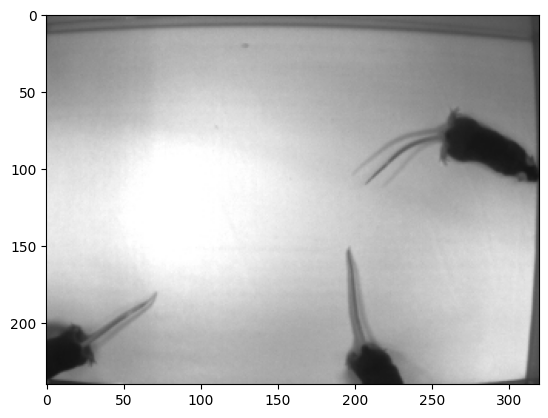

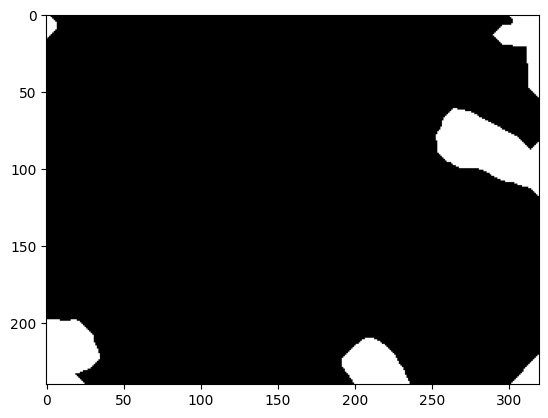

In [22]:
# test 1 frame
# TriMouse
#ruta_imagen = r'/img0734.png'
ruta_imagen = r'/img1246b.png'
# 4 mice
#ruta_imagen = r'/240513_3w_073b_076b_f_int_mask_287_jpg.rf.b61bb34b8ed0cab3271de0a6ded8a112.jpg'
# 3 mice
#ruta_imagen = r'/240712_3w_148b_151b_154b_m_rec_1000model_mp4-0217_jpg.rf.42e6e12fa3b10f4d122bf6d31281f10d.jpg'
thres = 12
frame = read_image(0, ruta_carpeta, img_name = ruta_imagen)
clean_frame = clean_image(frame, thres)
clean_frame = erode_image(clean_frame)

blobs = detect_blobs(clean_frame, ruta_imagen)
print("Found %2d blob(s)." % len(blobs))
for b in blobs:
    print("blob area = %2d" % b["area"])
    print("iou = %.2f" % b["iou"])
    print("rs = %.2f" % b["rs"])
    print("rect_similarity = %.2f" % b["rect_similarity"])
#    plt.imshow(cv.cvtColor(b["roi_image"], cv.COLOR_BGR2RGB))
#    plt.show()

hist = cv.calcHist([clean_frame], [0], None, [256], [0,256])

plt.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
plt.show()
plt.imshow(cv.cvtColor(clean_frame, cv.COLOR_BGR2RGB))
plt.show()



In [25]:
# Compute all frames
# Detect blobs and their areas
thres = BW_THRES
total_areas = []
total_blobs = []
for i, img in enumerate(df['img_path']):
    frame = read_image(i, ruta_carpeta, img)
    clean_frame = clean_image(frame, thres)
    clean_frame = erode_image(clean_frame)
    blobs = detect_blobs(clean_frame, img)
    # show number of blobs and image name
#    print("Image:", img, " - Found %2d blob(s)." % len(blobs))
    total_blobs.append(blobs)
    for b in blobs:
#        print("blob area = %2d" % b["area"])
#        if b["area"] < 3000:
        total_areas.append(int(b["area"]))
        process_blob(b)
#    display_results(frame, blobs, thres, write_image_flag=True)
total_blobs_flat = [d for sublist in total_blobs for d in sublist]
df_blobs = pd.DataFrame(total_blobs_flat)

n_points: 2
Final D: 20000
n_points: 2
Final D: 20000
n_points: 2
Final D: 20000
n_points: 2
Final D: 20000
n_points: 3
Increasing D to: 22000.0
n_points: 3
Increasing D to: 24000.0
n_points: 2
Final D: 24000.0
n_points: 2
Final D: 20000
n_points: 2
Final D: 20000
n_points: 2
Final D: 20000
n_points: 3
Increasing D to: 22000.0
n_points: 2
Final D: 22000.0
n_points: 2
Final D: 20000
n_points: 2
Final D: 20000
n_points: 3
Increasing D to: 22000.0
n_points: 2
Final D: 22000.0
n_points: 2
Final D: 20000
n_points: 3
Increasing D to: 22000.0
n_points: 2
Final D: 22000.0
n_points: 4
Increasing D to: 22000.0
n_points: 4
Increasing D to: 24000.0
n_points: 4
Increasing D to: 26400.000000000004
n_points: 4
Increasing D to: 29304.000000000007
n_points: 3
Increasing D to: 32849.78400000001
n_points: 3
Increasing D to: 36463.26024000001
n_points: 2
Final D: 36463.26024000001
n_points: 3
Increasing D to: 22000.0
n_points: 2
Final D: 22000.0
n_points: 4
Increasing D to: 22000.0
n_points: 4
Increasing 

In [ ]:
#print(len(total_blobs))
#print(total_blobs)

In [ ]:


#plt.hist(total_areas, bins=range(min(total_areas), max(total_areas)+2), align="left", rwidth=0.8)
#plt.ylim(0,4)
#plt.xlabel("Valor")
#plt.ylabel("Frecuencia")
#plt.title("Distribución de valores (Histograma)")
#plt.show()

In [ ]:
#valores_unicos, frecuencias = np.unique(total_areas, return_counts=True)
#plt.bar(valores_unicos, frecuencias)
#plt.xlabel("Valor")
#plt.ylim(0,4)
#plt.ylabel("Frecuencia")
#plt.title("Distribución de valores (Barras)")
#plt.show()

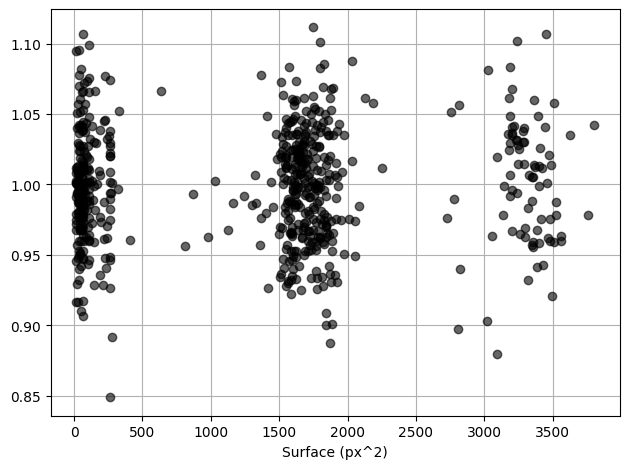

In [26]:
#plt.boxplot(total_areas, vert=False, widths=0.5, patch_artist=True,
#            boxprops=dict(facecolor="lightblue", color="blue"),
#            medianprops=dict(color="red"),
#            whiskerprops=dict(color="blue"),
#            capprops=dict(color="blue"))
x = total_areas
y = np.random.normal(1, 0.04, size=len(total_areas))  # jitter en vertical
plt.plot(x, y, "o", alpha=0.6, color="black")
plt.xlabel("Surface (px^2)")
plt.grid(True)
plt.tight_layout()
#plt.title("Distribución de valores (Boxplot)")
plt.show()

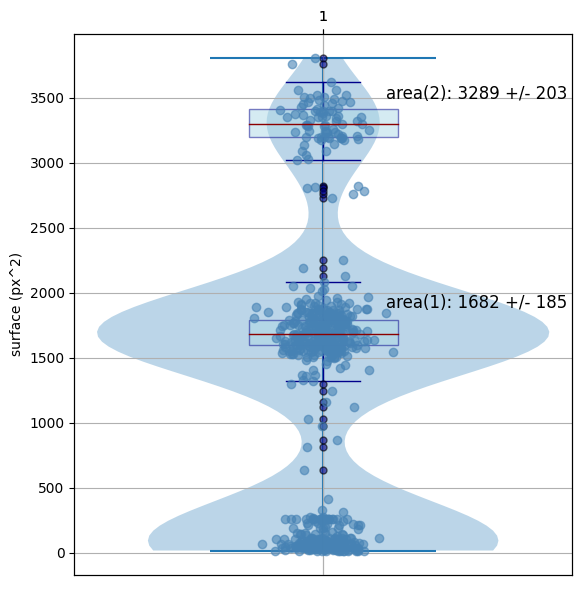

In [61]:
mice_areas = [v for v in total_areas if MIN_AREA <= v <=MAX_AREA]
overlap_areas = [v for v in total_areas if v > MAX_AREA]
mice_areas_mean = np.mean(mice_areas)
mice_areas_std = np.std(mice_areas)
overlap_areas_mean = np.mean(overlap_areas)
overlap_areas_std = np.std(overlap_areas)

fig, ax1 = plt.subplots(figsize=(6, 6))

ax1.violinplot(total_areas, vert=True, widths=1)
x = total_areas
y = np.random.normal(1, 0.04, size=len(total_areas))  # jitter en vertical
x_min_1 = 714
x_min_2 = 2566
yl = np.linspace(min(total_areas)-1, max(total_areas)+1, 100)
x_y = gaussian_kde(x, bw_method=0.4)(yl)
peaks, _ = find_peaks(x_y)
for p in peaks:
    x_max = x[p]
    y_max = y[p]
#    plt.axvline(x_max, color='green', linestyle='--', linewidth=2, 
#           label=f'{x_max:.0f}')
#    plt.text( x_max + 200, 1.2, f"Mean: {x_max:.0f}", color="black", ha="left")

plt.text( 1.14, mice_areas_mean+200, f"area(1): {mice_areas_mean:.0f} +/- {mice_areas_std:.0f}", color="black", ha="left",fontsize=12)
plt.text( 1.14, overlap_areas_mean+200, f"area(2): {overlap_areas_mean:.0f} +/- {overlap_areas_std:.0f}", color="black", ha="left", fontsize=12)

#plt.text( mice_areas_mean + 600, 1.2, f"+1 SD: {mice_areas_std:.0f}", color="black", ha="left")
#plt.text( mice_areas_mean - 600, 1.2, f"-1 SD: {mice_areas_std:.0f}", color="black", ha="left")

#plt.axvline(x_min_1, color='green', linestyle='--', linewidth=2, 
#           label=f'{x_max:.0f}')

#plt.axvline(x_min_2, color='green', linestyle='--', linewidth=2, 
#           label=f'{x_max:.0f}')

ax1.set_ylabel("surface (px^2)")
ax1.grid()
#ax1.set_xlim(0.9, 1.1)
ax1.xaxis.set_visible(False)
ax2 = ax1.twiny()
ax2.boxplot(mice_areas, vert=True, widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='DarkBlue', alpha=0.5),
    medianprops=dict(color='darkred'),
    whiskerprops=dict(color='DarkBlue'),
    capprops=dict(color='DarkBlue'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='DarkBlue', alpha=0.6))

plt.boxplot(overlap_areas, vert=True, widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='DarkBlue', alpha=0.5),
    medianprops=dict(color='darkred'),
    whiskerprops=dict(color='DarkBlue'),
    capprops=dict(color='DarkBlue'),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='DarkBlue', alpha=0.6))

plt.plot(y, x, "o", alpha=0.6, color="steelblue")
plt.ylabel("Blob Surface (px^2)")
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
3354/2

1677.0

In [ ]:
#n_blobs_zero = sum(1 for sublist in total_blobs for b in sublist if b.get("type") == 0)
#n_blobs_mice = sum(1 for sublist in total_blobs for b in sublist if b.get("type") == 1)
#n_blobs_overlap = sum(1 for sublist in total_blobs for b in sublist if b.get("type") == 2)
#print(n_blobs_zero)
#print(n_blobs_mice)
#print(n_blobs_overlap)

In [ ]:
#df = pd.DataFrame({
#    "Posición": range(len(total_areas)),
#    "Magnitud": total_areas
#})
#
## Violinplot de la magnitud en función de la posición
#plt.figure(figsize=(10, 4))
#plt.grid(True)
#sns.violinplot(x="Posición", y="Magnitud", data=df, inner="point", scale="width")
#plt.title("Violinplot: magnitud en función de la posición en el array")
#plt.show()

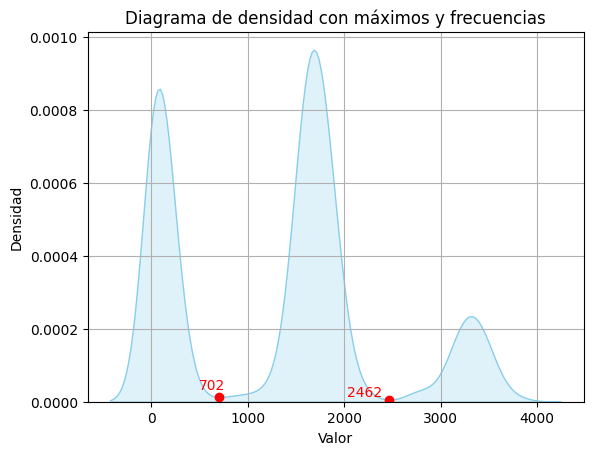

In [ ]:
from scipy.signal import find_peaks

x = np.linspace(min(total_areas)-1, max(total_areas)+1, 10)
kde = sns.kdeplot(total_areas, bw_adjust=0.5).get_lines()[0].get_data()
plt.cla()  # limpiar para graficar de nuevo sin duplicados
sns.kdeplot(total_areas, fill=True, bw_adjust=0.5, color="skyblue")
xk, yk = kde
peaks, _ = find_peaks(1-yk)

# Calcular frecuencia real de cada valor
valores_unicos, frecuencias = np.unique(total_areas, return_counts=True)

# Dibujar los máximos locales con anotaciones
for p in peaks:
    xpeak, ypeak = xk[p], yk[p]
    # Buscar el entero más cercano en tus datos
    idx = (np.abs(valores_unicos - xpeak)).argmin()
    freq = frecuencias[idx]
    plt.plot(xpeak, ypeak, "ro")
    plt.text(xpeak * (1 - 0.1), ypeak* (1 + 1.5), f"{xpeak:.0f}", ha="center", color="red")

plt.title("Diagrama de densidad con máximos y frecuencias")
plt.grid(True)
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.show()

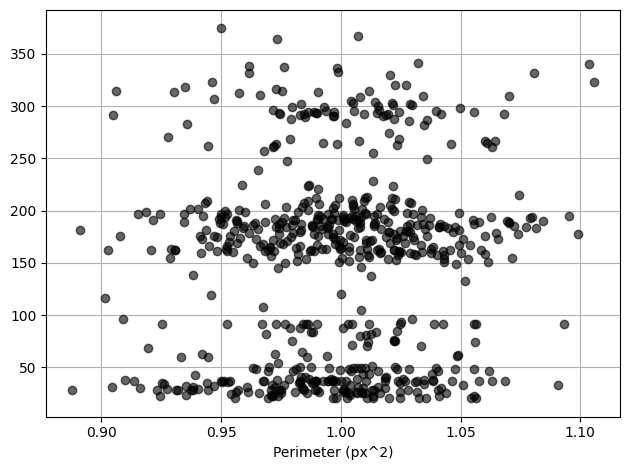

In [ ]:
# Plot perimeteres
for blobs in total_blobs:
    for blob in blobs:
        y = blob["perimeter"]
        x = np.random.normal(1, 0.04, size=1)  # jitter en vertical
        plt.plot(x, y, "o", alpha=0.6, color="black")
plt.xlabel("Perimeter (px^2)")
plt.grid(True)
plt.tight_layout()
#plt.title("Distribución de valores (Boxplot)")
plt.show()

In [ ]:
#concluimos añadiendo etiqueta al blob si hay o no solapamiento, según su área.
# observando las gráficas (luego se le puede dar una matemática)
MIN_AREA = 702
MAX_AREA = 2462
mice_area_mean = statistics.mean(mice_areas)
mice_area_std = statistics.stdev(mice_areas)
for blobs in total_blobs:
    for blob in blobs:
        if blob["area"] < MIN_AREA:
            blob["type"] = 0 # no mice
        elif (blob["area"] >= MIN_AREA) & (blob["area"] <= MAX_AREA) :
            blob["type"] = 1 # one mice
        elif blob["area"] > mice_area_mean + mice_area_std:
            blob["type"] = 2 # more than one mice



In [ ]:
print(mice_area_mean + 2*mice_area_std)
print(mice_area_mean - 2*mice_area_std)

2038.3097262870895
1332.4599898012386


Calibración de [d,l,S] para el convexity defects

 * S, superficie del raton en un rango [Smin, Smax] marcado por los diagramas anteriores
 * l, longitud mínima a la que poder segmentar
 * D, distancia umbral.
 * np, numero de puntos de inflexión. Límites dentro de un rango marcado por el numero de ratones. 

 Representar en cada blob con/sin solapamiento, la distancia "D" de los candidatos a puntos de inflexión


In [ ]:
print(blob.keys())

dict_keys(['id', 'img_path', 'contour', 'origin', 'size', 'roi_image', 'area', 'perimeter', 'iou', 'rs', 'rect_similarity', 'type', 'ellipses', 'ellipse_area', 'hull', 'split_contours'])


In [ ]:
df_defects ={
    "scores_0":[]
    , "scores_1":[]
    , "scores_2":[]
    , "d_0":[]
    , "d_1":[]
    , "d_2":[]
    , "w_0":[]
    , "w_1":[]
    , "w_2":[]
}
for blobs in total_blobs:
    for blob in blobs:
        contour = blob["contour"]
        contour = contour.squeeze()  # Elimina dimensiones extra si es necesario
        contour.tolist()
        blob["hull"] = cv.convexHull(contour)
        blob["d"] = []
        hull_idx = cv.convexHull(contour, returnPoints=False)
        defects = cv.convexityDefects(contour, hull_idx) 
        distancias = np.zeros(len(blob["contour"]))
        widths = np.zeros(len(blob["contour"]))
        scores = np.zeros(len(blob["contour"]))
#        print(len(blob["contour"]))
        if defects is not None :
#            for i, defect in enumerate(np.squeeze(defects, 1)):#defects.shape[0]):
            for i in range( defects.shape[0] ):
              s,e,f,dist = defects[i,0]
              start = tuple(contour[s])
              end = tuple(contour[e])
              far = tuple(contour[f])
              distancias[f] = dist
              width = np.linalg.norm(np.array(start) - np.array(end))
              widths[f] = width
              scores[f] = dist*width              
#            print(scores)
              if blob["type"] == 0: 
                  df_defects["scores_0"].append(dist*width)
                  df_defects["d_0"].append(dist)
                  df_defects["w_0"].append(width)
              elif blob["type"] == 1:
                  df_defects["scores_1"].append(dist*width)
                  df_defects["d_1"].append(dist)
                  df_defects["w_1"].append(width)
              elif blob["type"] == 2:
                  df_defects["scores_2"].append(dist*width)
                  df_defects["d_2"].append(dist)
                  df_defects["w_2"].append(width)
        blob["distancias"] = distancias
        blob["widths"] = widths
        blob["scores"] = scores
#        print(blob["contour"])
#        print(blob["distancias"])
    #          print(d)
    #          for n, p in enumerate(blob["inter_points"]):
    #          cv.circle(frame_defects, p, 3, (0,0,255))



In [ ]:
print(len(blob["distancias"]))
print(range(len(blob["contour"])))

148
range(0, 148)


In [ ]:
print(df_defects.keys())

dict_keys(['scores_0', 'scores_1', 'scores_2', 'd_0', 'd_1', 'd_2', 'w_0', 'w_1', 'w_2'])


In [ ]:
print(blob.keys())

dict_keys(['id', 'img_path', 'contour', 'origin', 'size', 'roi_image', 'area', 'perimeter', 'iou', 'rs', 'rect_similarity', 'type', 'ellipses', 'ellipse_area', 'hull', 'split_contours', 'd', 'distancias', 'widths', 'scores'])


In [ ]:
print(df_defects["scores_0"])

[1277.3801313626261, 512.2889809472775, 1280.8809468486913, 2301.421517236684, 5119.4530957906045, 766.8976463648848, 13823.750576453556, 1024.9029222321496, 509.82349886995206, 766.8976463648848, 3069.609747182856, 512.2889809472775, 766.8976463648848, 512.2889809472775, 766.8976463648848, 4603.531253288067, 512.2889809472775, 10748.791187849916, 54256.34786824488, 512.2889809472775, 1026.2475334927728, 1024.9029222321496, 3069.609747182856, 254.91174943497603, 254.91174943497603, 254.91174943497603, 254.91174943497603, 766.8976463648848, 254.91174943497603, 254.91174943497603, 254.91174943497603, 254.91174943497603, 8189.793648194074, 24068.361971683906, 254.91174943497603, 254.91174943497603, 254.91174943497603, 16646.303253275182, 3326.453516885513, 9991.418818165917, 766.8976463648848, 3326.453516885513, 9991.418818165917, 766.8976463648848, 21760.0, 512.2889809472775, 1024.9029222321496, 254.91174943497603, 766.8976463648848, 4092.0043988246152, 254.91174943497603, 3579.511698542

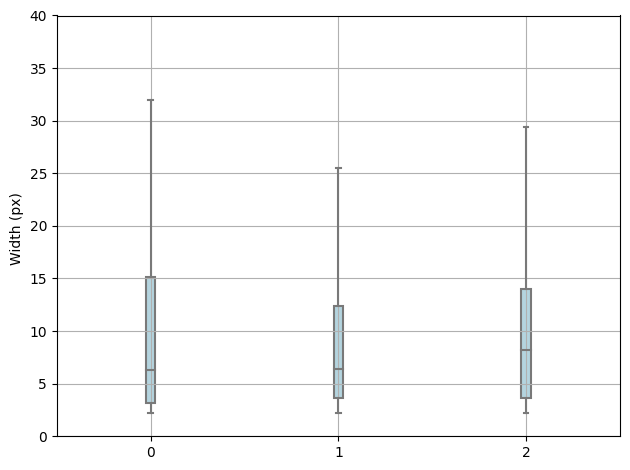

In [ ]:
#plt.violinplot(distances_0, vert=False, widths=0.5, showmeans = True)
#sns.violinplot(data = [distances_1, distances_2], alpha = 0.6, inner_kws=dict(box_width=15, whis_width=2, color=".8"))
#sns.boxplot([df_defects["scores_0"],df_defects["scores_1"],df_defects["scores_2"]], width=0.05,color="lightblue", fliersize=0)
sns.boxplot([df_defects["w_0"],df_defects["w_1"],df_defects["w_2"]], width=0.05,color="lightblue", fliersize=0)
#plt.boxplot(data=[distances_1, distances_2])


#plt.xlim(-100,2000)
plt.ylim(0,40)
plt.ylabel("Width (px) ")
plt.grid(True)
plt.tight_layout()
plt.show()

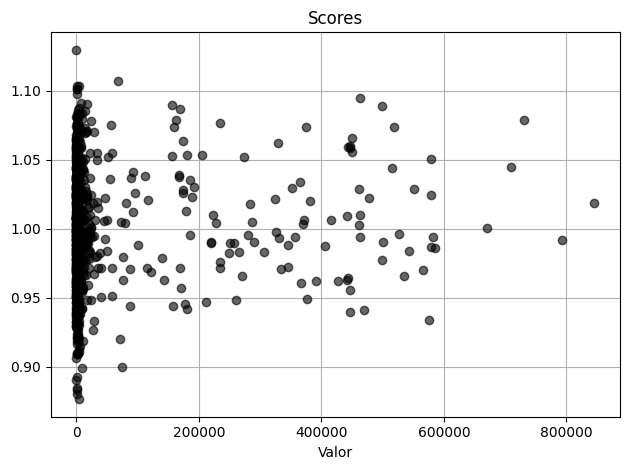

In [ ]:
x = df_defects["scores_2"]
y = np.random.normal(1, 0.04, size=len(x))  # jitter en vertical
plt.plot(x, y, "o", alpha=0.6, color="black")
#plt.xlim(-50, 1000)
plt.xlabel("Valor")
plt.title("Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

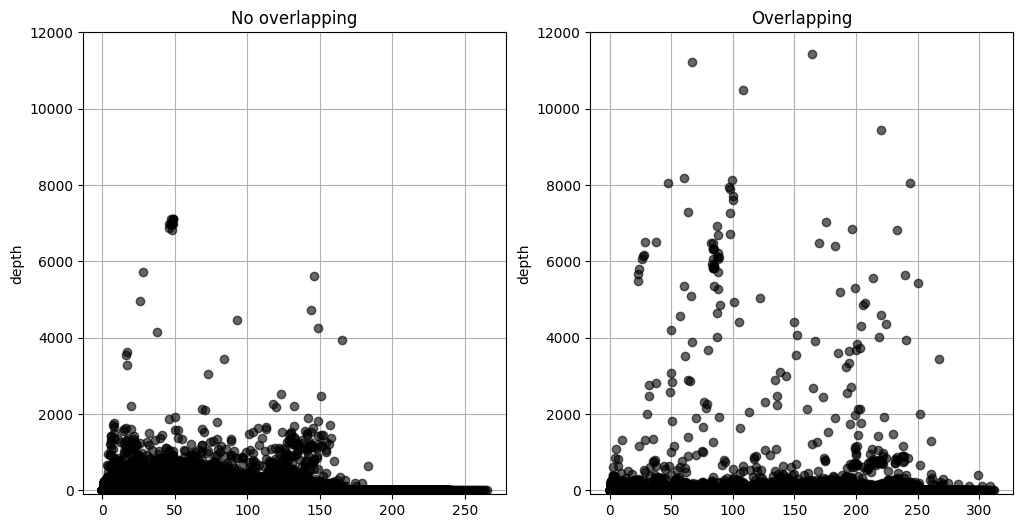

In [ ]:
plt.figure(figsize=(12,6))
#plt.figure()
ax1 = plt.subplot(121)
for blobs in total_blobs:
    for b in blobs:
        cnt = b["contour"]
        distancias = b["distancias"]
        if b["type"] == 1:
            if distancias.any() > 0:
                ax1.plot(range(len(cnt)), distancias,'o', alpha=0.6, color="black" )
plt.ylim(-100,12000)
plt.title("No overlapping")
plt.ylabel("depth")
plt.grid(True)

ax2 = plt.subplot(122)
for blobs in total_blobs:
    for b in blobs:
        cnt = b["contour"]
        distancias = b["distancias"]
        if b["type"] == 2:
            if distancias.any() > 0:
                ax2.plot(range(len(cnt)), distancias,'o', alpha=0.6, color="black")
plt.ylim(-100,12000)
plt.title("Overlapping")
plt.ylabel("depth")
plt.grid(True)


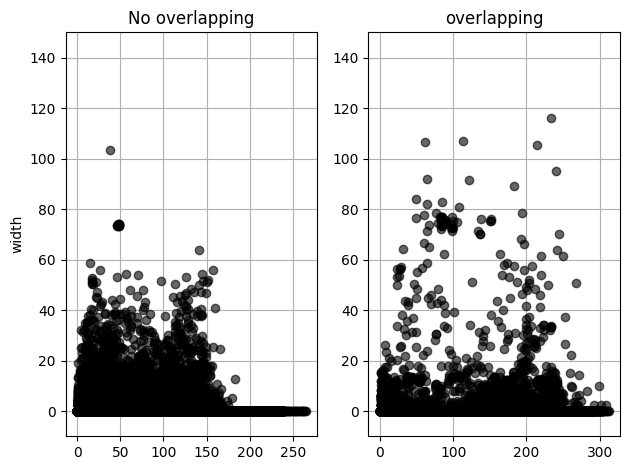

In [ ]:

ax3 = plt.subplot(121)
for blobs in total_blobs:
    for b in blobs:
        cnt = b["contour"]
        distancias = b["widths"]
        if b["type"] == 1:
            if distancias.any() > 0:
                ax3.plot(range(len(cnt)), distancias,'o', alpha=0.6, color="black",label=f'Blob {idx+1}' )
plt.ylim(-10,150)
plt.title("No overlapping")
plt.ylabel("width")
#plt.xlabel("Contour point")
plt.grid(True)
ax4 = plt.subplot(122)
for blobs in total_blobs:
    for b in blobs:
        cnt = b["contour"]
        distancias = b["widths"]
        if b["type"] == 2:
            if distancias.any() > 0:
                ax4.plot(range(len(cnt)), distancias,'o', alpha=0.6, color="black",label=f'Blob {idx+1}' )
plt.ylim(-10,150)
plt.title("overlapping")
#plt.xlabel("Contour point")
plt.grid(True)
plt.tight_layout()
plt.show()


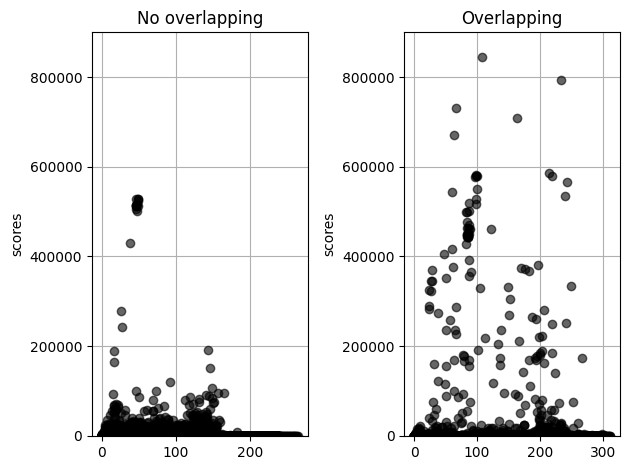

In [ ]:
ax5 = plt.subplot(121)
for blobs in total_blobs:
    for b in blobs:
        cnt = b["contour"]
        distancias = b["scores"]
        if b["type"] == 1:
            if distancias.any() > 0:
                ax5.plot(range(len(cnt)), distancias,'o', alpha=0.6, color="black",label=f'Blob {idx+1}' )
plt.ylim(-1000,900000)
plt.title("No overlapping")
plt.ylabel("scores")
#plt.xlabel("Contour point")
plt.grid(True)

ax6 = plt.subplot(122)
for blobs in total_blobs:
    for b in blobs:
        cnt = b["contour"]
        distancias = b["scores"]
        if b["type"] == 2:
            if distancias.any() > 0:
                ax6.plot(range(len(cnt)), distancias,'o', alpha=0.6, color="black",label=f'Blob {idx+1}' )
plt.ylim(-1000,900000)
plt.title("Overlapping")
plt.ylabel("scores")
#plt.xlabel("Contour point")
plt.tight_layout()
plt.grid(True)
plt.show()



Is Mice an Ellipse?
* Analizamos IoU de la elipse con el blob del mouse.
* Analizamos error cuadrático medio de las distancias radiales

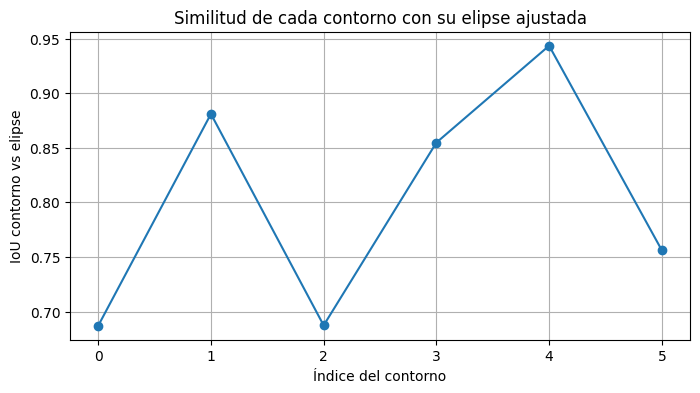

In [ ]:
# --- ejemplo con imagen binaria y contornos ---
thre = BW_THRES
#ruta_imagen = r'/img0734.png'
#ruta_carpeta + ruta_imagen
img = cv.imread(ruta_carpeta + ruta_imagen)
#_, thresh = cv.threshold(img, 49, 255, cv.THRESH_BINARY)
thresh = clean_image(img, thres)
thresh = erode_image(thresh)
contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# calcular IoU para cada contorno
ious = [iou_contour_ellipse(c, img.shape) for c in contours]

# --- representación ---
plt.figure(figsize=(8,4))
plt.plot(range(len(ious)), ious, marker="o", linestyle="-")
plt.xlabel("Índice del contorno")
plt.ylabel("IoU contorno vs elipse")
plt.title("Similitud de cada contorno con su elipse ajustada")
plt.grid(True)
plt.show()

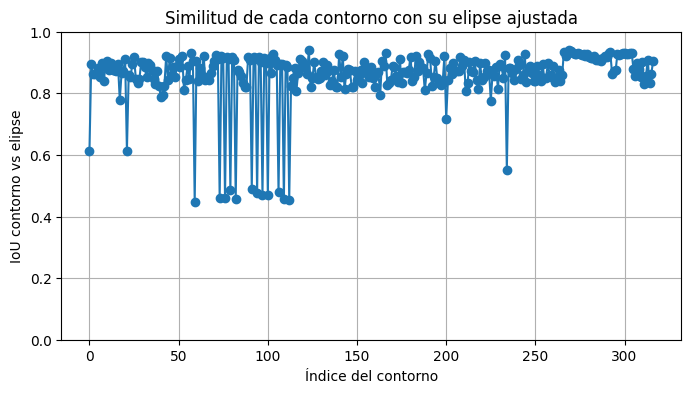

In [ ]:
ious = []
for blobs in total_blobs:
    for blob in blobs:
        if blob["type"] == 1:
            iou = iou_contour_ellipse(blob["contour"], frame.shape)
            if iou != 0:
                ious.append(iou)
plt.figure(figsize=(8,4))
plt.plot(range(len(ious)), ious, marker="o", linestyle="-")
plt.xlabel("Índice del contorno")
plt.ylabel("IoU contorno vs elipse")
plt.title("Similitud de cada contorno con su elipse ajustada")
plt.grid(True)
plt.ylim(0,1)
plt.show()

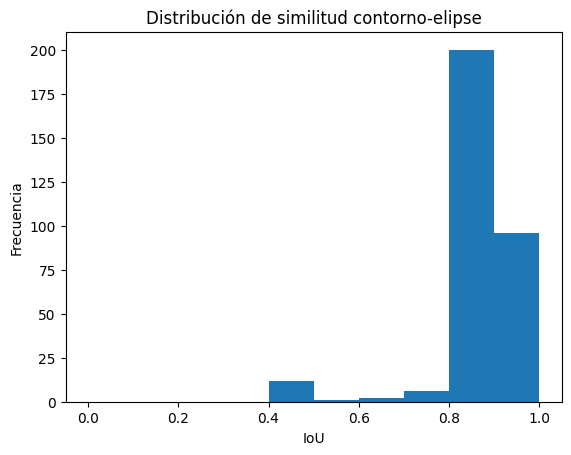

In [ ]:
plt.hist(ious, bins=10, range=(0,1))
plt.xlabel("IoU")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitud contorno-elipse")
plt.show()


Generating RectSim for type 0
Generating RectSim for type 1
Generating RectSim for type 2


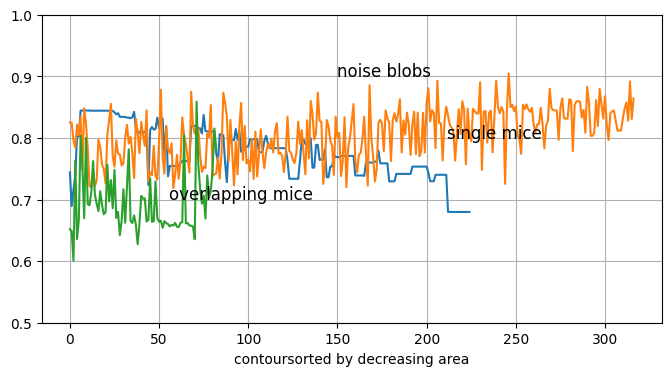

In [ ]:
# Rectangular Similarity Score. Cuánto se parece el contorno a su bounding rect
def gen_rect_similarity(type_blob):
    print("Generating RectSim for type %d" % type_blob)
    rect_sim = []
    total_blobs_flat = [d for sublist in total_blobs for d in sublist]
    #for blobs in total_blobs:
    blobs_sorted = sorted(total_blobs_flat, key=lambda x: x["area"], reverse=True)
    #    for blob in blobs_sorted:
    for blob in blobs_sorted:
        if blob["type"] == type_blob:
            rect_sim.append(blob["rect_similarity"])
    return rect_sim
rect_sim = []
labels = ["noise blobs", "single mice", "overlapping mice"]
for t in [0,1,2]:
    rect_sim.append(gen_rect_similarity(t))
plt.figure(figsize=(8,4))
for i, rect_sim in enumerate (rect_sim):
    plt.plot(range(len(rect_sim)), rect_sim, linestyle="-")
    plt.text( 2*len(rect_sim)/3, 0.9 - i*0.1, labels[i], fontsize=12, color="black")
#    plt.text(len(rect_sim)-1, rect_sim[-1], f"{rect_sim

plt.xlabel("contoursorted by decreasing area")
plt.grid(True)
plt.ylim(0.5,1)
plt.show()

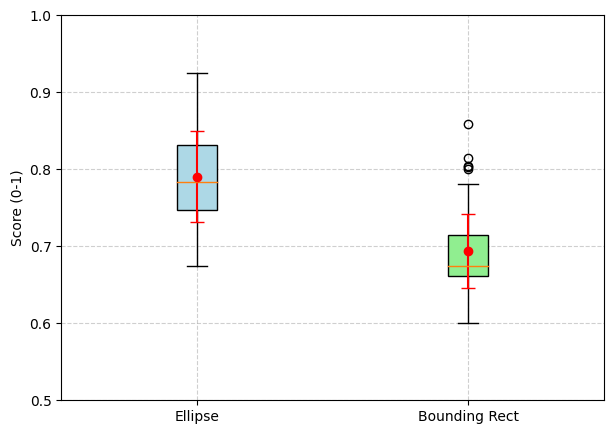

In [ ]:
data = [rss, rect_sim]
labels = ["Ellipse", "Bounding Rect"]

plt.figure(figsize=(7,5))
box = plt.boxplot(data, labels=labels, patch_artist=True)

# colorear cajas
colors = ["lightblue", "lightgreen"]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# calcular medias y std y añadir al gráfico
for i, scores in enumerate(data, start=1):
    mean = np.mean(scores)
    std  = np.std(scores)
    plt.scatter(i, mean, color="red", marker="o", zorder=3, label="Media" if i==1 else "")
    plt.errorbar(i, mean, yerr=std, color="red", fmt="none", capsize=5)

plt.ylim(0.5,1)
plt.ylabel("Score (0-1)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
df_blobs.columns

Index(['id', 'img_path', 'contour', 'origin', 'size', 'roi_image', 'area',
       'perimeter', 'iou', 'rs', 'rect_similarity', 'type', 'ellipses',
       'ellipse_area', 'hull', 'split_contours', 'segments', 'intersections',
       'inter_points'],
      dtype='object')

In [ ]:
df_blobs["ellipses"][30]
max_n = df_blobs["ellipses"].apply(len).max()
print(max_n)



2


EVALUATION.
Cálculo de TP, TN, FP, FN.
* TP: Elipses cuyo RMSE respecto al punto ground truth más cercano es menor que un umbral.
* TN: Elipses cuyo RMSE... es mayor que el umbral.
* FN: Ratones que no se han encontrado.
 


In [ ]:
test_file = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\deeplabcut\labeled-data-ordered\CollectedData_dlc.csv'
df_ground_truth = pd.DataFrame()
df_ground_truth = pd.read_csv(test_file)
df_ground_truth.head(20)

,scorer,dlc,dlc.1,dlc.2,dlc.3,dlc.4,dlc.5,dlc.6,dlc.7,dlc.8,...,dlc.62,dlc.63,dlc.64,dlc.65,dlc.66,dlc.67,dlc.68,dlc.69,dlc.70,dlc.71
0,individuals,mus1,mus1,mus1,mus1,mus1,mus1,mus1,mus1,mus1,...,mus3,mus3,mus3,mus3,mus3,mus3,mus3,mus3,mus3,mus3
1,bodyparts,snout,snout,leftear,leftear,rightear,rightear,shoulder,shoulder,spine1,...,spine4,spine4,tailbase,tailbase,tail1,tail1,tail2,tail2,tailend,tailend
2,coords,x,y,x,y,x,y,x,y,x,...,x,y,x,y,x,y,x,y,x,y
3,/img0038.png,577.0738982187231,251.0082247294906,575.3425399593766,273.5158821009952,596.5516786363714,272.65020297132196,586.1635290802924,281.7398338328911,586.1635290802924,...,NaN,NaN,NaN,NaN,NaN,NaN,127.01268085145685,332.08101456949316,162.72616092026604,331.8041658867892
4,/img0303.png,608.6823002384388,64.52077380905499,599.5926693768697,72.7840745922997,613.6402807083857,86.00535584549127,599.1795043377074,84.35269568884232,592.5688637111116,...,98.23955027247223,106.37117408591845,114.9010628721575,116.01731295942045,139.16256367520796,127.41729526446827,164.88560067121327,155.47879016920132,177.74711916921592,185.29412850548022
5,/img0502.png,391.6471699771854,235.93936498314736,411.53389946420856,212.30042238536515,384.51796506674316,206.67210271922653,401.0277027540831,199.5428978087843,404.7799158648422,...,101.12823717208212,99.68967706042972,116.58679305910454,109.58315282812407,141.9388247138213,125.6600509506274,166.05417189757628,147.9203714279397,188.62366349262902,178.21914096650363
6,/img0707.png,257.3440332490244,293.13160905008624,263.3644381053884,325.8138068417765,284.579198075433,312.33956740134283,279.70553700123355,326.9605506239411,288.592801313009,...,165.9229305514636,227.64039709550153,161.69290753146925,214.95032803551857,149.0028384714863,187.4551784055555,148.15683386748742,146.4239551116106,157.03988220947554,118.50580317964813
7,/img1138.png,280.5087701635501,316.5274748962508,286.18023465904184,290.0606405839558,260.1860223880378,299.9857034510664,270.58370729643946,283.44393200588206,265.85748688352965,...,574.6312641868317,137.98898003862422,566.3454782313877,156.0670584868657,549.0206530518229,185.44393596525813,531.3192012379199,209.17141392857508,507.2150966402645,233.2755185262304
8,/img1331.png,608.5274787976398,367.97728503505004,601.0230525761217,362.4740391392701,600.5227574946871,386.4882030481282,591.0171509474308,369.47817027935366,575.0077083415254,...,544.6293163108479,113.1035109963922,556.4080534247164,103.24224271501399,589.2789476959771,93.10705031470859,616.3974354697672,100.22907740681508,634.2025032000334,113.92528335317371
9,/img1501.png,442.834413410453,200.11096701580038,472.12863344437835,207.3620115786532,466.9078813591243,182.70846006495367,482.5701376148864,189.95950462780647,494.7518924804791,...,475.5193165256127,124.02018734728036,490.2791046451348,129.8554524177891,527.6934512736909,138.09347369380146,560.9887872642407,141.52598255880662,594.9706250277918,143.5854878778097


In [ ]:
field = 'spine2'
df_clean = pd.DataFrame()
df_clean["img_path"] = df_ground_truth["scorer"]
df_clean.drop([0,1,2], inplace=True)
col = df_ground_truth.loc[:, (df_ground_truth.iloc[0] == 'mus1') & (df_ground_truth.iloc[1] == field) & (df_ground_truth.iloc[2] == 'x')]
df_clean["mus_1_x"] = col
col = df_ground_truth.loc[:, (df_ground_truth.iloc[0] == 'mus1') & (df_ground_truth.iloc[1] == field) & (df_ground_truth.iloc[2] == 'y')]
df_clean["mus_1_y"] = col
col = df_ground_truth.loc[:, (df_ground_truth.iloc[0] == 'mus2') & (df_ground_truth.iloc[1] == field) & (df_ground_truth.iloc[2] == 'x')]
df_clean["mus_2_x"] = col
col = df_ground_truth.loc[:, (df_ground_truth.iloc[0] == 'mus2') & (df_ground_truth.iloc[1] == field) & (df_ground_truth.iloc[2] == 'y')]
df_clean["mus_2_y"] = col
col = df_ground_truth.loc[:, (df_ground_truth.iloc[0] == 'mus3') & (df_ground_truth.iloc[1] == field) & (df_ground_truth.iloc[2] == 'x')]
df_clean["mus_3_x"] = col
col = df_ground_truth.loc[:, (df_ground_truth.iloc[0] == 'mus3') & (df_ground_truth.iloc[1] == field) & (df_ground_truth.iloc[2] == 'y')]
df_clean["mus_3_y"] = col
df_ground_truth = df_clean
df_ground_truth.head(30)


,img_path,mus_1_x,mus_1_y,mus_2_x,mus_2_y,mus_3_x,mus_3_y
3,/img0038.png,585.2978499506191,313.337122065965,96.94862418821859,320.6372283383545,45.34231945379248,398.52469841844044
4,/img0303.png,584.7187279670292,109.96892811690094,118.75671058567993,338.86136203326316,69.30113365196624,85.0327456687777
5,/img0502.png,410.0330142199049,165.77297981195258,527.4234560583649,422.39847716466613,69.59278316255637,81.44858111374327
6,/img0707.png,296.9066937337021,355.91583112359655,515.3951513434035,163.80427650680974,179.03600191344594,257.6735605374612
7,/img1138.png,258.2955342228739,251.30563319809525,338.64128124234094,220.5852005141814,586.6833164856594,107.48222265721671
8,/img1331.png,556.9970854098818,373.48053093083,492.9593149862602,337.45928506754285,525.1807038670187,132.82604755914863
9,/img1501.png,511.57431586629764,184.44871076003832,467.61059178775145,321.89416673586015,440.16447521605966,107.88739568175617
10,/img1587.png,592.8533382415478,256.663386069942,333.5988057383355,283.08709640290306,505.6749986601078,108.45313141934668
11,/img1677.png,517.7079152366416,269.58933863952836,418.5924334784283,339.1280923884774,602.9904619298707,221.3422441495456
12,/img0000_1.png,74.67337285390434,293.42866628130423,258.6109509352304,207.2333580760636,437.72697286947255,399.3713930740071


In [ ]:
df_ground_truth.describe()

,img_path,mus_1_x,mus_1_y,mus_2_x,mus_2_y,mus_3_x,mus_3_y
count,112,112,112,112,112,112,111
unique,112,102,102,103,106,102,100
top,/img0038.png,397.95,169.363,503.006,152.535,63.398,175.186
freq,1,4,4,3,4,3,3


Convertimos el DF de blobs en DF img con las columnas:
* img_path num_blobs numb_mice mus_i_x/y mus_i_type mus_i_area


In [ ]:
df_blobs.columns

Index(['id', 'img_path', 'contour', 'origin', 'size', 'roi_image', 'area',
       'perimeter', 'iou', 'rs', 'rect_similarity', 'type', 'ellipses',
       'ellipse_area', 'hull', 'split_contours', 'segments', 'intersections',
       'inter_points'],
      dtype='object')

In [ ]:
df_blobs.describe()

,id,area,perimeter,iou,rs,rect_similarity,type
count,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000
mean,1.576000,1327.692000,149.951510,0.816803,0.884260,0.780262,0.772800
std,1.293871,1069.828037,90.201697,0.095382,0.064759,0.056522,0.664746
min,0.000000,18.000000,20.485281,0.446566,0.674339,0.600677,0.000000
25%,0.000000,109.500000,48.384776,0.754190,0.832053,0.744044,0.000000
50%,1.000000,1600.000000,167.237588,0.844521,0.909415,0.783377,1.000000
75%,3.000000,1802.500000,195.237588,0.887218,0.938522,0.826319,1.000000
max,5.000000,3803.000000,374.173661,0.942203,0.967489,0.904576,2.000000


In [ ]:
max_n = df_blobs["ellipses"].apply(len).max()

# --- Crear las columnas dinámicamente ---
for i in range(max_n):
    df_blobs[f"mus_{i+1}_x"] = df_blobs["ellipses"].apply(
        lambda lst: lst[i][0][0] if i < len(lst) else None
    )
    df_blobs[f"mus_{i+1}_y"] = df_blobs["ellipses"].apply(
        lambda lst: lst[i][0][1] if i < len(lst) else None
    )
    df_blobs[f"mus_{i+1}_type"] = df_blobs["type"]  # mismo valor para todas las elipses de esa fila
    df_blobs[f"mus_{i+1}_area"] = df_blobs["ellipse_area"].apply(
        lambda lst: lst[i] if i < len(lst) else None
    )   
# --- Resultado ---
print(df_blobs.drop(columns=["ellipses"]))


     id      img_path                                            contour  \
0     0    /img00.png  [[[318, 231]], [[317, 232]], [[316, 232]], [[3...   
1     1    /img00.png  [[[157, 157]], [[156, 158]], [[155, 158]], [[1...   
2     2    /img00.png  [[[310, 0]], [[310, 1]], [[310, 2]], [[310, 3]...   
3     0  /img0000.png  [[[4, 233]], [[3, 234]], [[2, 235]], [[1, 236]...   
4     1  /img0000.png  [[[145, 189]], [[144, 190]], [[143, 190]], [[1...   
..   ..           ...                                                ...   
620   1    /img53.png  [[[237, 49]], [[236, 50]], [[235, 51]], [[234,...   
621   2    /img53.png  [[[312, 39]], [[311, 40]], [[310, 40]], [[309,...   
622   0    /img59.png  [[[153, 143]], [[152, 144]], [[151, 145]], [[1...   
623   1    /img59.png  [[[252, 44]], [[251, 45]], [[250, 45]], [[249,...   
624   2    /img59.png  [[[313, 39]], [[312, 40]], [[311, 40]], [[310,...   

         origin       size                                          roi_image  \
0    (

In [ ]:
df_blobs.ellipse_area

0                                            []
1      [1071.0567956957475, 1972.8228878893772]
2                            [3058.30645838354]
3                                            []
4                          [1686.8172991777622]
                         ...                   
620                        [1884.8356273332026]
621                          [1672.93950776496]
622                        [1962.5399090121578]
623                        [1847.3395422977378]
624                        [1636.1823376150435]
Name: ellipse_area, Length: 625, dtype: object

In [ ]:
df_img = pd.DataFrame()
# copiamos df_blobs pero solamente las columnas img_path, type, mus_1_x, mus_1_y, mus_2_x, mus_2_y, mus_3_x, mus_3_y
df_img = df_blobs[["img_path","mus_1_x", "mus_1_y",  "mus_1_type", "mus_1_area", "mus_2_x", "mus_2_y", "mus_2_type", "mus_2_area"]].copy()
df_img.head(20)

,img_path,mus_1_x,mus_1_y,mus_1_type,mus_1_area,mus_2_x,mus_2_y,mus_2_type,mus_2_area
0,/img00.png,NaN,NaN,0,NaN,NaN,NaN,0,NaN
1,/img00.png,103.285820,226.850372,2,1071.056796,137.79071,192.611557,2,1972.822888
2,/img00.png,306.440552,79.116241,1,3058.306458,NaN,NaN,1,NaN
3,/img0000.png,NaN,NaN,0,NaN,NaN,NaN,0,NaN
4,/img0000.png,141.709152,214.423782,1,1686.817299,NaN,NaN,1,NaN
5,/img0000.png,88.107948,127.836327,1,1905.340452,NaN,NaN,1,NaN
6,/img0000.png,209.838974,79.292488,1,1851.612069,NaN,NaN,1,NaN
7,/img0000.png,NaN,NaN,0,NaN,NaN,NaN,0,NaN
8,/img0000_1.png,218.573944,206.443283,1,1826.392318,NaN,NaN,1,NaN
9,/img0000_1.png,30.688763,146.524414,1,1967.857235,NaN,NaN,1,NaN


In [ ]:
# Construccion de un DF con todas las filas de un mismo img_path fusionadas
# y las columnas mus_i_x, mus_i_y, mus_i_type renumeradas consecutivamente
def merge_blob_rows(df_blob):
    # Detectar todas las columnas mus_i_x, mus_i_y, mus_i_type
    mus_cols = [c for c in df_blob.columns if c.startswith("mus_")]
    
    # Grupo por img_path
    grouped = df_blob.groupby("img_path")
    merged_rows = []
    for img_path, group in grouped:
        new_row = {"img_path": img_path}
        i_new = 1  # índice acumulativo para nueva numeración
        
        # recorrer cada fila del grupo
        for _, row in group.iterrows():
            # buscar todas las parejas mus_i_x/y/type válidas
            for i in range(1, 100):  # límite alto por seguridad
                x_col, y_col, t_col, s_col = f"mus_{i}_x", f"mus_{i}_y", f"mus_{i}_type", f"mus_{i}_area"
                if s_col not in row or pd.isna(row[s_col]):
                    continue
                # copiar datos a nuevas columnas consecutivas
                new_row[f"mus_{i_new}_x"] = row[x_col]
                new_row[f"mus_{i_new}_y"] = row[y_col]
                new_row[f"mus_{i_new}_type"] = row[t_col]
                new_row[f"mus_{i_new}_area"] = row[s_col]
                i_new += 1
                
        merged_rows.append(new_row)
    
    # reconstruir dataframe fusionado
    df_merged = pd.DataFrame(merged_rows)
    return df_merged

# --- ejemplo de uso ---
df_merged = merge_blob_rows(df_blobs)
print(df_merged)


NameError: name 'df_blobs' is not defined

In [ ]:
# Como las imágenes originales se redujeron en tamaño a la mitad, ahora
# hay que multiplicar las coordenadas x,y por 2 para volver a la escala original
# y adaptar las áreas (multiplicar por 4)
scale_factor = 2
for i in range(1, 10):  # suponiendo un máximo de 9 ratones por imagen
    x_col = f"mus_{i}_x"
    y_col = f"mus_{i}_y"
    area_col = f"mus_{i}_area"
    if x_col in df_merged.columns:
        df_merged[x_col] = df_merged[x_col] * scale_factor
    if y_col in df_merged.columns:
        df_merged[y_col] = df_merged[y_col] * scale_factor
    if area_col in df_merged.columns:
        df_merged[area_col] = df_merged[area_col] * (scale_factor ** 2)
df_merged.head(20)

,img_path,mus_1_x,mus_1_y,mus_1_type,mus_1_area,mus_2_x,mus_2_y,mus_2_type,mus_2_area,mus_3_x,...,rmse_9,mus_1_rmse,mus_2_rmse,mus_3_rmse,mus_4_rmse,mus_5_rmse,mus_6_rmse,mus_7_rmse,mus_8_rmse,mus_9_rmse
0,/img00.png,413.143280,907.401489,2,17136.908731,551.162842,770.446228,2,31565.166206,1225.762207,...,NaN,7.362036,7.059847,19.533810,NaN,NaN,NaN,NaN,NaN,NaN
1,/img0000.png,566.836609,857.695129,1,26989.076787,352.431793,511.345306,1,30485.447225,839.355896,...,NaN,7.047129,6.837843,6.402985,NaN,NaN,NaN,NaN,NaN,NaN
2,/img0000_1.png,874.295776,825.773132,1,29222.277090,122.755051,586.097656,1,31485.715760,523.828796,...,NaN,15.685972,5.465565,5.698239,NaN,NaN,NaN,NaN,NaN,NaN
3,/img0000_2.png,1216.708740,683.516968,1,22656.302998,326.609070,669.218872,1,33180.051297,1018.672302,...,NaN,11.063970,6.197622,17.272202,NaN,NaN,NaN,NaN,NaN,NaN
4,/img0000_20.png,125.727661,834.712280,1,29525.274535,1153.709106,842.625305,1,27679.982846,326.193390,...,NaN,11.732109,18.918440,19.005380,NaN,NaN,NaN,NaN,NaN,NaN
5,/img0000_4.png,397.538330,886.651672,1,29538.797981,267.893707,248.242523,2,25103.863743,143.435089,...,NaN,13.397090,11.653264,6.253202,NaN,NaN,NaN,NaN,NaN,NaN
6,/img0038.png,62.846016,822.799133,2,28772.883963,161.860870,655.851135,2,26973.370536,1191.028564,...,NaN,13.768609,20.549752,12.111224,NaN,NaN,NaN,NaN,NaN,NaN
7,/img0067.png,915.294250,898.218262,2,27924.336161,1034.486206,772.505005,2,26892.730724,94.425446,...,NaN,6.249562,19.484858,31.300115,NaN,NaN,NaN,NaN,NaN,NaN
8,/img0074.png,312.709564,651.666504,1,27061.953385,170.020996,360.208588,1,33421.925806,1231.354492,...,NaN,18.046092,2.912646,12.388709,NaN,NaN,NaN,NaN,NaN,NaN
9,/img0082.png,464.596771,467.087708,1,30238.448750,126.582405,144.178757,1,27659.353897,1207.680176,...,NaN,5.281505,15.907906,6.824072,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# imprime valors no Nan de la columna mus_4_area y dice en qué fila está
for i, v in enumerate(df_merged["mus_4_area"]):
    if not pd.isna(v):
        print(f"Fila {i}: mus_4_area = {v}")    
print(df_merged["img_path"][69  ])

Fila 69: mus_4_area = 18789.903766885363
/img1246b.png


<AxesSubplot:xlabel='n_mice'>

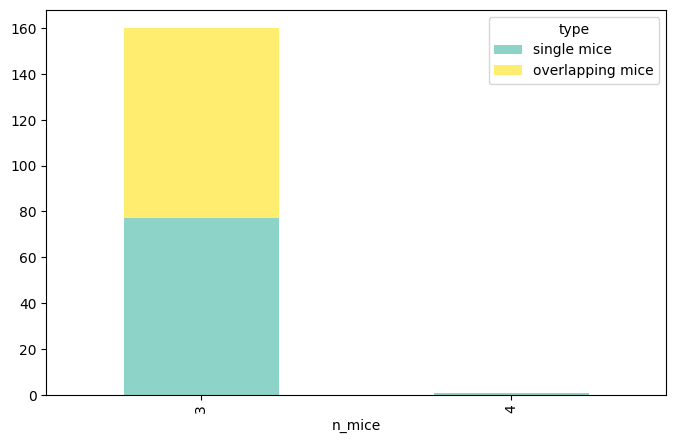

In [ ]:
# Representación gráfica del número de entradas por número de ratones detectados y tipo de blob
type_labels = {0: "noise blobs", 1: "single mice", 2: "overlapping mice"}
df_merged["n_mice"] = df_merged[[col for col in df_merged.columns if col.startswith("mus_") and col.endswith("_x")]].notna().sum(axis=1)
df_merged["type"] = df_merged[[col for col in df_merged.columns if col.startswith("mus_") and col.endswith("_type")]].max(axis=1)     
df_count = df_merged.groupby(["n_mice", "type"]).size().unstack(fill_value=0)
df_count = df_count.rename(columns=type_labels).sort_index()    
df_count.plot(kind="bar", stacked=True, figsize=(8,5), colormap="Set3")


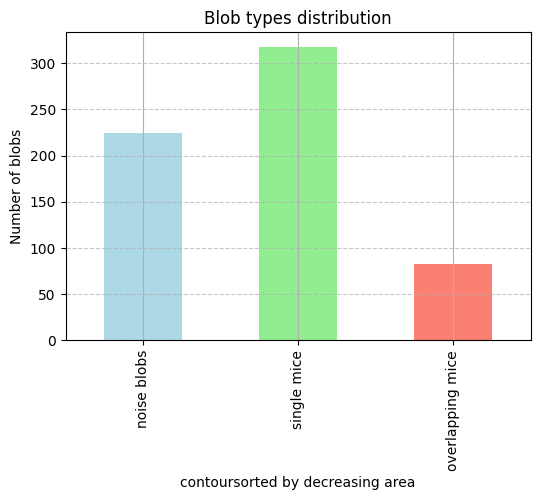

In [ ]:
# Representación gráfica del número de blobs por tipo
type_labels = {0: "noise blobs", 1: "single mice", 2: "overlapping mice"}
df_blobs["type_label"] = df_blobs["type"].map(type_labels)
df_count = df_blobs["type_label"].value_counts().reindex(type_labels.values(), fill_value=0)
df_count.plot(kind="bar", figsize=(6,4), color=["lightblue", "lightgreen", "salmon"])
plt.ylabel("Number of blobs")   
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(True)

c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


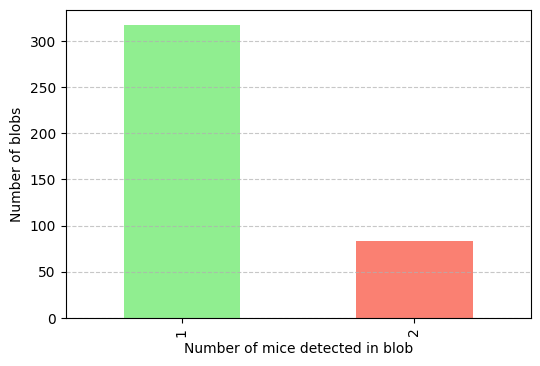

In [ ]:
# Representación gráfica del número de ratones detectados en los blobs de tipo 1 y 2
df_mice = df_blobs[df_blobs["type"].isin([1,2])]
df_mice["n_mice"] = df_mice[[col for col in df_mice.columns if col.startswith("mus_") and col.endswith("_x")]].notna().sum(axis=1)
df_count = df_mice["n_mice"].value_counts().sort_index()
df_count.plot(kind="bar", figsize=(6,4), color=["lightgreen", "salmon"])
plt.ylabel("Number of blobs")
plt.xlabel("Number of mice detected in blob")
plt.grid(axis="y", linestyle="--", alpha=0.7)

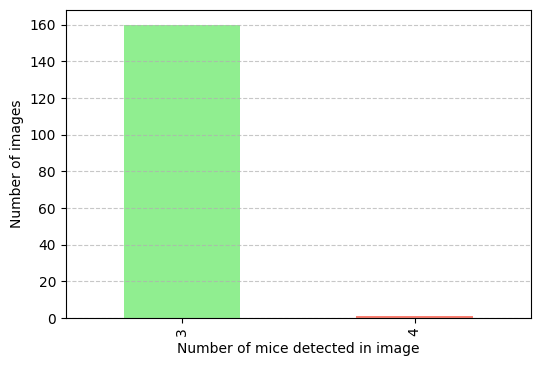

In [ ]:
# Número de ratones detectados por imagen
# Número total de ratones detectados
df_merged["n_mice"] = df_merged[[col for col in df_merged.columns if col.startswith("mus_") and col.endswith("_x")]].notna().sum(axis=1)
df_count = df_merged["n_mice"].value_counts().sort_index()
df_count.plot(kind="bar", figsize=(6,4), color=["lightgreen", "salmon", "orange", "purple", "cyan"])
plt.ylabel("Number of images")
plt.xlabel("Number of mice detected in image")
plt.grid(axis="y", linestyle="--", alpha=0.7)


In [ ]:
# Número total de ratones detectados
total_mice = df_merged["n_mice"].sum()
print("Total mice detected:", total_mice)

# Numero total de imágenes procesadas
total_images = len(df_merged)
print("Total images processed:", total_images)  
print("Total number of mice:", total_images*3)

Total mice detected: 484
Total images processed: 161
Total number of mice: 483


c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is de

Overall RMSE: 14.94
Total mice compared: 335
Images with mismatch in number of mice: 1
RMSE for images with 3 mice: 14.96 over 333 mice
RMSE for images with 2 mice: 11.33 over 2 mice


c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  y_true = check_array(y_true, ensure_2d=False, dtype=dtype)
c:\ProgramData\anaconda3\envs\dlc-live\lib\site-packages\sklearn\metrics\_regression.py:95: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is de

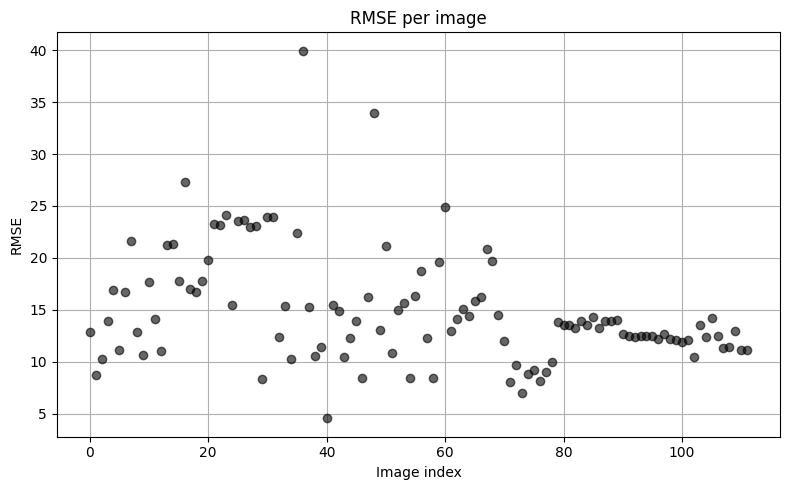

In [ ]:
# Calculo de los RMSE entre las posiciones de los ratones detectados y las posiciones reales utilizando sklearn
# Cono los ID de los ratones (mus_1, mus_2, mus_3) no coincide con los ID de la verdad (mus1, mus2, mus3),
# calculamos todas las combinaciones posibles y nos quedamos con la que da menor RMSE
# Contabilizar también los casos en que no coinciden el número de ratones detectados y el número de ratones en la verdad
# Dar el resultado para el total de número de ratones detectados
# y también desglosado por número de ratones detectados (1, 2, 3, ...)
from sklearn.metrics import mean_squared_error
import itertools
def calculate_rmse(df_detected, df_truth):
    total_rmse = 0
    total_mice = 0
    mismatch_count = 0
    rmse_by_n_mice = {}
    
    for _, row in df_detected.iterrows():
        img_path = row["img_path"]
        truth_row = df_truth[df_truth["img_path"] == img_path]
        if truth_row.empty:
            continue
        
        # Obtener posiciones detectadas
        detected_positions = []
        for i in range(1, 10):  # suponiendo un máximo de 9 ratones por imagen
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in row and y_col in row and not pd.isna(row[x_col]) and not pd.isna(row[y_col]):
                detected_positions.append((row[x_col], row[y_col]))
        
        # Obtener posiciones de la verdad
        truth_positions = []
        for i in range(1, 4):  # suponiendo un máximo de 3 ratones en la verdad
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in truth_row.columns and y_col in truth_row.columns and not pd.isna(truth_row.iloc[0][x_col]) and not pd.isna(truth_row.iloc[0][y_col]):
                truth_positions.append((truth_row.iloc[0][x_col], truth_row.iloc[0][y_col]))
        
        n_detected = len(detected_positions)
        n_truth = len(truth_positions)
        
        if n_detected != n_truth:
            mismatch_count += 1
        
        if n_detected == 0 or n_truth == 0:
            continue
        
        # Calcular RMSE para todas las permutaciones posibles
        min_rmse = float('inf')
        for perm in itertools.permutations(detected_positions, min(n_detected, n_truth)):
            if len(perm) != len(truth_positions):
                continue
            rmse = mean_squared_error(truth_positions, perm, squared=False)
            if rmse < min_rmse:
                min_rmse = rmse
        
        total_rmse += min_rmse * min(n_detected, n_truth)
        total_mice += min(n_detected, n_truth)
        if n_truth not in rmse_by_n_mice:
            rmse_by_n_mice[n_truth] = {"total_rmse": 0, "count": 0}
        rmse_by_n_mice[n_truth]["total_rmse"] += min_rmse * min(n_detected, n_truth)
        rmse_by_n_mice[n_truth]["count"] += min(n_detected, n_truth)
        # Mostramos los resultados
    overall_rmse = total_rmse / total_mice if total_mice > 0 else 0
    print(f"Overall RMSE: {overall_rmse:.2f}")
    print(f"Total mice compared: {total_mice}")
    print(f"Images with mismatch in number of mice: {mismatch_count}")
    for n_mice, stats in rmse_by_n_mice.items():
        avg_rmse = stats["total_rmse"] / stats["count"] if stats["count"] > 0 else 0
        print(f"RMSE for images with {n_mice} mice: {avg_rmse:.2f} over {stats['count']} mice")
# Representación gráfica mediante puntos del RMSE individual para cada i de cada mus_i
    plt.figure(figsize=(8,5))
    rmse_values = []
    for _, row in df_detected.iterrows():
        img_path = row["img_path"]
        truth_row = df_truth[df_truth["img_path"] == img_path]
        if truth_row.empty:
            continue
        
        detected_positions = []
        for i in range(1, 10):
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in row and y_col in row and not pd.isna(row[x_col]) and not pd.isna(row[y_col]):
                detected_positions.append((row[x_col], row[y_col]))
        
        truth_positions = []
        for i in range(1, 4):
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in truth_row.columns and y_col in truth_row.columns and not pd.isna(truth_row.iloc[0][x_col]) and not pd.isna(truth_row.iloc[0][y_col]):
                truth_positions.append((truth_row.iloc[0][x_col], truth_row.iloc[0][y_col]))
        
        n_detected = len(detected_positions)
        n_truth = len(truth_positions)
        
        if n_detected == 0 or n_truth == 0:
            continue
        
        min_rmse = float('inf')
        for perm in itertools.permutations(detected_positions, min(n_detected, n_truth)):
            if len(perm) != len(truth_positions):
                continue
            rmse = mean_squared_error(truth_positions, perm, squared=False)
            if rmse < min_rmse:
                min_rmse = rmse
        
        rmse_values.append(min_rmse)
    plt.plot(range(len(rmse_values)), rmse_values, 'o', alpha=0.6, color="black")
    plt.xlabel("Image index")
    plt.ylabel("RMSE")
    plt.title("RMSE per image")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
        
    return overall_rmse
   

# --- ejemplo de uso ---
overall_rmse = calculate_rmse(df_merged, df_ground_truth)


In [ ]:
print("Mean RMSE: %.2f px" % np.mean(overall_rmse))


Mean RMSE: 14.94 px


In [ ]:
# Calculo de los RMSE entre las posiciones de los ratones detectados y las posiciones reales utilizando sklearn
# Como los ID de los ratones (mus_1, mus_2, mus_3) no coincide con los ID de la verdad (mus1, mus2, mus3),
# calculamos todas las combinaciones posibles de un ratón detectado con cada ratón de la verdad
# y nos quedamos con la que da menor RMSE para ese ratón detectado.
# Repetimos para el siguiente ratón detectado, pero sin repetir los ratones de la verdad ya asignados. 
# Guardar para cada ratón detectado su RMSE individual como un campo nuevo en el dataframe df_merged
# y luego representamos gráficamente esos RMSE individuales
from sklearn.metrics import mean_squared_error
import itertools

def calculate_individual_rmse(df_detected, df_truth):
    individual_rmses = {f"mus_{i}_rmse": [] for i in range(1, 10)}
    
    for _, row in df_detected.iterrows():
        img_path = row["img_path"]
        truth_row = df_truth[df_truth["img_path"] == img_path]
        if truth_row.empty:
            continue
        
        detected_positions = []
        for i in range(1, 10):  # suponiendo un máximo de 9 ratones por imagen
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in row and y_col in row and not pd.isna(row[x_col]) and not pd.isna(row[y_col]):
                detected_positions.append((i, (row[x_col], row[y_col])))
        
        truth_positions = []
        for i in range(1, 4):  # suponiendo un máximo de 3 ratones en la verdad
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in truth_row.columns and y_col in truth_row.columns and not pd.isna(truth_row.iloc[0][x_col]) and not pd.isna(truth_row.iloc[0][y_col]):
                truth_positions.append((i, (truth_row.iloc[0][x_col], truth_row.iloc[0][y_col])))
        
        n_detected = len(detected_positions)
        n_truth = len(truth_positions)
        
        if n_detected == 0 or n_truth == 0:
            continue
        
        used_truth_indices = set()
        for det_idx, det_pos in detected_positions:
            min_rmse = float('inf')
            best_truth_idx = -1
            for truth_idx, truth_pos in truth_positions:
                if truth_idx in used_truth_indices:
                    continue
                rmse = mean_squared_error([truth_pos], [det_pos], squared=False)
                if rmse < min_rmse:
                    min_rmse = rmse
                    best_truth_idx = truth_idx
            if best_truth_idx != -1:
                used_truth_indices.add(best_truth_idx)
                individual_rmses[f"mus_{det_idx}_rmse"].append(min_rmse)
            else:
                individual_rmses[f"mus_{det_idx}_rmse"].append(None)
                # No hay ratón de la verdad disponible para este ratón detectado
    # Añadir las columnas de RMSE individual al dataframe original
    for i in range(1, 10):
        rmse_col = f"mus_{i}_rmse"
        if rmse_col in individual_rmses:
            df_detected[rmse_col] = pd.Series(individual_rmses[rmse_col])
    return df_detected
# --- ejemplo de uso ---
df_merged = calculate_individual_rmse(df_merged, df_ground_truth)
df_merged.head()





NameError: name 'df_ground_truth' is not defined

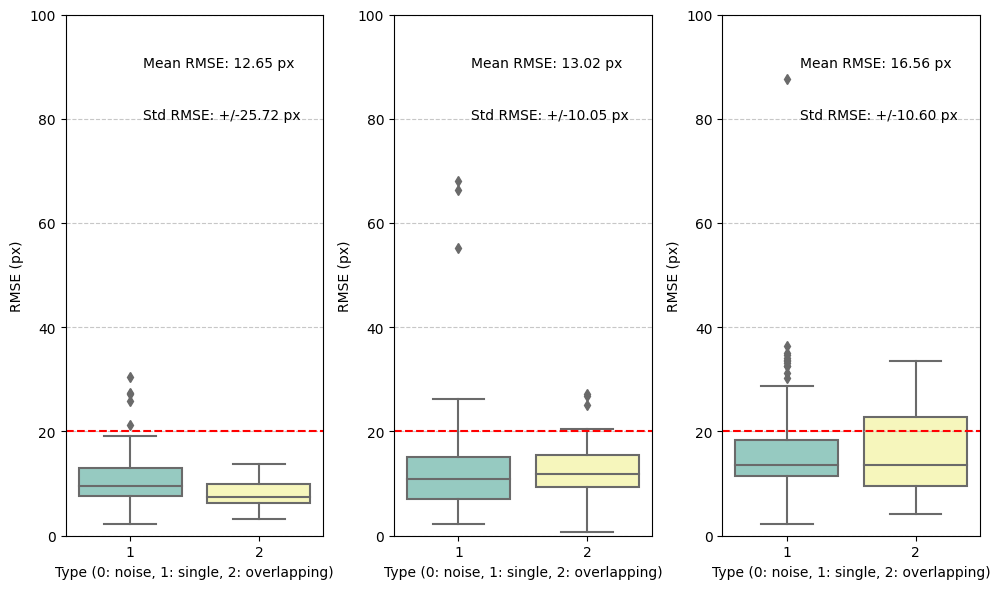

In [ ]:
# Representar gráficamente los RMSE individuales según el mus_1_type, mus_2_type, mus_3_type
# Incluir como texto en la gráfica el RMSE medio para cada tipo de blob (0, 1, 2)

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
for i in range(1, 4):  # suponiendo un máximo de 3
    rmse_col = f"mus_{i}_rmse"
    type_col = f"mus_{i}_type"
    if rmse_col in df_merged.columns and type_col in df_merged.columns:
        plt.subplot(1, 3, i)
        sns.boxplot(x=df_merged[type_col], y=df_merged[rmse_col], palette="Set3")
        plt.text(0.1, 90, f"Mean RMSE: {df_merged[rmse_col].mean():.2f} px", fontsize=10, color="black")
        plt.text(0.1, 80, f"Std RMSE: +/-{df_merged[rmse_col].std():.2f} px", fontsize=10, color="black")
        # Dibujamos una linea horizontal en el valor rmse=20
        plt.axhline(y=20, color='r', linestyle='--', label='Threshold 20 px')

        plt.xlabel("Type (0: noise, 1: single, 2: overlapping)")
        plt.ylabel("RMSE (px)")
        plt.ylim(0, 100)  # ajustar según los datos
        plt.grid(axis="y", linestyle="--", alpha=0.7)   
plt.tight_layout()
plt.show()  

In [ ]:
# Contamos el número de valores de RMSE por encima de 20 px para cada mus_i_type
threshold = 20
for i in range(1, 4):
    rmse_col = f"mus_{i}_rmse"
    type_col = f"mus_{i}_type"
    if rmse_col in df_merged.columns and type_col in df_merged.columns:
        count_above_threshold = df_merged[df_merged[rmse_col] > threshold].groupby(type_col).size()
        print(f"mus_{i}_rmse counts above {threshold} px:")
        print(count_above_threshold)
# Consideramos True Positives como los ratones detectados (mus_i) con RMSE <= 20 px
# False Positives como los ratones detectados (mus_i) con RMSE > 20 px
# False Negatives como los ratones en la verdad (mus1, mus2, mus3) que no tienen ningún mus_i asignado con RMSE <= 20 px
# Calculamos Precision, Recall y F1-Score para cada mus_i_type
from sklearn.metrics import precision_score, recall_score, f1_score
def calculate_classification_metrics(df_detected, df_truth, threshold=20):
    metrics = {f"mus_{i}": {"TP": 0, "FP": 0, "FN": 0} for i in range(1, 10)}
    
    for _, row in df_detected.iterrows():
        img_path = row["img_path"]
        truth_row = df_truth[df_truth["img_path"] == img_path]
        if truth_row.empty:
            continue
        
        detected_positions = []
        for i in range(1, 10):
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            rmse_col = f"mus_{i}_rmse"
            if x_col in row and y_col in row and rmse_col in row and not pd.isna(row[x_col]) and not pd.isna(row[y_col]) and not pd.isna(row[rmse_col]):
                detected_positions.append((i, row[rmse_col]))
        
        truth_positions = []
        for i in range(1, 4):
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in truth_row.columns and y_col in truth_row.columns and not pd.isna(truth_row.iloc[0][x_col]) and not pd.isna(truth_row.iloc[0][y_col]):
                truth_positions.append(i)
        
        detected_assigned = set()
        for det_idx, det_rmse in detected_positions:
            if det_rmse <= threshold:
                metrics[f"mus_{det_idx}"]["TP"] += 1
                detected_assigned.add(det_idx)
            else:
                metrics[f"mus_{det_idx}"]["FP"] += 1
        
        for truth_idx in truth_positions:
            if truth_idx not in detected_assigned:
                metrics[f"mus_{truth_idx}"]["FN"] += 1
    
    # Calcular Precision, Recall y F1-Score
    results = {}
    for mus, counts in metrics.items():
        TP = counts["TP"]
        FP = counts["FP"]
        FN = counts["FN"]
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        results[mus] = {"Precision": precision, "Recall": recall, "F1-Score": f1, "TP": TP, "FP": FP, "FN": FN}
    return results
# --- ejemplo de uso ---
metrics = calculate_classification_metrics(df_merged, df_ground_truth, threshold=20)
for mus, vals in metrics.items():
    print(f"{mus}: Precision={vals['Precision']:.2f}, Recall={vals['Recall']:.2f}, F1-Score={vals['F1-Score']:.2f}, TP={vals['TP']}, FP={vals['FP']}, FN={vals['FN']}")
    


mus_1_rmse counts above 20 px:
mus_1_type
1    6
dtype: int64
mus_2_rmse counts above 20 px:
mus_2_type
1    6
2    5
dtype: int64
mus_3_rmse counts above 20 px:
mus_3_type
1    17
2     8
dtype: int64
mus_1: Precision=0.92, Recall=0.58, F1-Score=0.71, TP=65, FP=6, FN=47
mus_2: Precision=0.90, Recall=0.57, F1-Score=0.70, TP=64, FP=7, FN=48
mus_3: Precision=0.77, Recall=0.49, F1-Score=0.60, TP=54, FP=16, FN=57
mus_4: Precision=0.00, Recall=0.00, F1-Score=0.00, TP=0, FP=0, FN=0
mus_5: Precision=0.00, Recall=0.00, F1-Score=0.00, TP=0, FP=0, FN=0
mus_6: Precision=0.00, Recall=0.00, F1-Score=0.00, TP=0, FP=0, FN=0
mus_7: Precision=0.00, Recall=0.00, F1-Score=0.00, TP=0, FP=0, FN=0
mus_8: Precision=0.00, Recall=0.00, F1-Score=0.00, TP=0, FP=0, FN=0
mus_9: Precision=0.00, Recall=0.00, F1-Score=0.00, TP=0, FP=0, FN=0


In [ ]:
# Calculamos PRecision, Recall y F1-Score globales para todos los mus_i juntos
from sklearn.metrics import precision_score, recall_score, f1_score
def calculate_overall_metrics(df_detected, df_truth, threshold=20):
    total_TP = total_FP = total_FN = 0
    
    for _, row in df_detected.iterrows():
        img_path = row["img_path"]
        truth_row = df_truth[df_truth["img_path"] == img_path]
        if truth_row.empty:
            continue
        
        detected_positions = []
        for i in range(1, 10):
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            rmse_col = f"mus_{i}_rmse"
            if x_col in row and y_col in row and rmse_col in row and not pd.isna(row[x_col]) and not pd.isna(row[y_col]) and not pd.isna(row[rmse_col]):
                detected_positions.append((i, row[rmse_col]))
        
        truth_positions = []
        for i in range(1, 4):
            x_col = f"mus_{i}_x"
            y_col = f"mus_{i}_y"
            if x_col in truth_row.columns and y_col in truth_row.columns and not pd.isna(truth_row.iloc[0][x_col]) and not pd.isna(truth_row.iloc[0][y_col]):
                truth_positions.append(i)
        
        detected_assigned = set()
        for det_idx, det_rmse in detected_positions:
            if det_rmse <= threshold:
                total_TP += 1
                detected_assigned.add(det_idx)
            else:
                total_FP += 1
        
        for truth_idx in truth_positions:
            if truth_idx not in detected_assigned:
                total_FN += 1
    
    precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
    recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {"Precision": precision, "Recall": recall, "F1-Score": f1, "TP": total_TP, "FP": total_FP, "FN": total_FN}
# --- ejemplo de uso ---
overall_metrics = calculate_overall_metrics(df_merged, df_ground_truth, threshold=20)
print(f"Overall: Precision={overall_metrics['Precision']:.2f}, Recall={overall_metrics['Recall']:.2f}, F1-Score={overall_metrics['F1-Score']:.2f}, TP={overall_metrics['TP']}, FP={overall_metrics['FP']}, FN={overall_metrics['FN']}")


NameError: name 'df_ground_truth' is not defined

CROSS VALIDATION con BW_THRES